# Clean Gemma 4 + MedGemma Medical Quantization Benchmark

This simplified notebook benchmarks only:

- `google/gemma-4-E4B-it`
- `google/gemma-4-12B-it`
- `google/medgemma-1.5-4b-it`

Each model is tested as Baseline BF16/FP16, BitsAndBytes INT8, and BitsAndBytes INT4 NF4 on PubMedQA, MedQA, and MedMCQA. The old Gemma 2 runner, legacy MedGemma runner, AWQ/GPTQ section, and publishing cells are intentionally not included.


## 1. Runtime Check


In [1]:
import os, platform, subprocess, sys

def command_output(command):
    '''Return command output without failing the notebook.'''
    try:
        return subprocess.check_output(command, text=True, stderr=subprocess.STDOUT).strip()
    except Exception as exc:
        return f"Unavailable ({type(exc).__name__}: {exc})"

try:
    import torch
    gpu_available = torch.cuda.is_available()
    if gpu_available:
        props = torch.cuda.get_device_properties(0)
        print(f"GPU: {props.name}")
        print(f"Total GPU memory: {props.total_memory / 2**30:.2f} GiB")
    else:
        print("WARNING: No CUDA GPU is available. Select Runtime > Change runtime type > GPU.")
    print(f"CUDA reported by PyTorch: {torch.version.cuda}")
    print(f"PyTorch: {torch.__version__}")
except Exception as exc:
    print(f"PyTorch environment check failed: {exc}")

print(f"Python: {platform.python_version()}")
print("Driver / nvidia-smi:")
print(command_output(["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"]))


CUDA reported by PyTorch: None
PyTorch: 2.11.0+cpu
Python: 3.12.13
Driver / nvidia-smi:
Unavailable (FileNotFoundError: [Errno 2] No such file or directory: 'nvidia-smi')


## 2. Install Dependencies


In [2]:
%pip install -q --upgrade --upgrade-strategy only-if-needed \
  "transformers==5.14.1" "datasets==5.0.0" "accelerate==1.14.0" \
  "bitsandbytes==0.49.2" "huggingface_hub>=1.2,<2" \
  "sentencepiece>=0.2,<0.3" "psutil>=5.9,<8" "tqdm>=4.67,<5"

# Diagnostic only: any remaining lines are pre-existing runtime conflicts.
!python -m pip check


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 43.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 59.5 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.6 MB/s eta 0:00:0000:0100:01
ipython 7.34.0 requires jedi, which is not installed.


## 3. Imports


In [3]:
import gc
import importlib.metadata as importlib_metadata
import json
import math
import os
import platform
import random
import re
import shutil
import statistics
import subprocess
import sys
import threading
import time
import traceback
import warnings
from contextlib import nullcontext
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
import torch
import transformers
from datasets import load_dataset
from huggingface_hub import HfApi, notebook_login, scan_cache_dir
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed

def package_version(name):
    try:
        return importlib_metadata.version(name)
    except importlib_metadata.PackageNotFoundError:
        return "not installed"

print("Transformers:", transformers.__version__)
print("Datasets:", package_version("datasets"))
print("Accelerate:", package_version("accelerate"))
print("BitsAndBytes:", package_version("bitsandbytes"))


Transformers: 5.14.1
Datasets: 5.0.0
Accelerate: 1.14.0
BitsAndBytes: 0.49.2


## 4. Configuration


In [7]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
MODEL_ID = None
MODEL_REVISION = None

MODEL_FAMILIES = {
    "Gemma4-E4B": {"model_id": "google/gemma-4-E4B-it", "revision": None, "enabled": True},
    "Gemma4-12B": {"model_id": "google/gemma-4-12B-it", "revision": None, "enabled": True},
    "MedGemma": {"model_id": "google/medgemma-1.5-4b-it", "revision": None, "enabled": True},
}

RUN_PRECISIONS = {"Baseline": True, "INT8": True, "INT4-NF4": True}
REFERENCE_PRECISION = "Baseline"

BENCHMARKS = ["pubmedqa", "medqa", "medmcqa"]
DATASET_CONFIGS = {
    "pubmedqa": {"path": "qiaojin/PubMedQA", "name": "pqa_labeled", "split": "train", "revision": None},
    "medqa": {"path": "GBaker/MedQA-USMLE-4-options", "name": None, "split": "test", "revision": None},
    "medmcqa": {"path": "openlifescienceai/medmcqa", "name": None, "split": "validation", "revision": None},
}

MAX_SAMPLES_PER_DATASET = 300
MAX_NEW_TOKENS = 64
BATCH_SIZE = 1
NUM_WARMUP_RUNS = 5
NUM_TIMED_RUNS = 30
RANDOM_SEED = 42
OUTPUT_DIR = "/content/drive/MyDrive/gemma4_medgemma_benchmark_results/latest"
FIGURE_DIR = Path(OUTPUT_DIR) / "figures"

ENABLE_CPU_OFFLOAD_FALLBACK = False
CPU_OFFLOAD_FOLDER = f"{OUTPUT_DIR}/offload"
TRUST_REMOTE_CODE = False
MULTI_FAMILY_PREFIX = "clean_three_model"

PROMPT_TEMPLATE = '''You are answering a medical multiple-choice question.

{context_block}Question:
{question}

Choices:
{choices}

Select the single best answer.
Respond with only one letter: {allowed_letters}.'''

GENERATION_PARAMETERS = {
    "do_sample": False,
    "max_new_tokens": MAX_NEW_TOKENS,
    "use_cache": True,
}

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
set_seed(RANDOM_SEED)

ACTIVE_FAMILIES = [name for name, cfg in MODEL_FAMILIES.items() if cfg.get("enabled", True)]
ACTIVE_PRECISIONS = [name for name, enabled in RUN_PRECISIONS.items() if enabled]
CONFIGURATION_INDEX = {
    f"{family} {precision}": (family, precision)
    for family in ACTIVE_FAMILIES for precision in ACTIVE_PRECISIONS
}

print("Active models:", ACTIVE_FAMILIES)
print("Active precisions:", ACTIVE_PRECISIONS)
print("Results will be written to", OUTPUT_DIR)


Active models: ['Gemma4-E4B', 'Gemma4-12B', 'MedGemma']
Active precisions: ['Baseline', 'INT8', 'INT4-NF4']
Results will be written to /content/drive/MyDrive/gemma4_medgemma_benchmark_results/latest


## 5. Hugging Face Login

Run this if Hugging Face asks for access. MedGemma usually requires accepting terms on the model page first.


In [9]:
# Run when the selected model or dataset is gated.
notebook_login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


## 6. Load Datasets


In [10]:
def save_json(data, filename):
    '''Write JSON atomically enough for routine Colab use.'''
    path = Path(OUTPUT_DIR) / filename
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with temp_path.open("w", encoding="utf-8") as handle:
        json.dump(data, handle, indent=2, ensure_ascii=False, default=str)
    temp_path.replace(path)
    return path

def friendly_access_error(exc, resource):
    text = str(exc)
    if any(term in text.lower() for term in ("401", "403", "gated", "unauthorized")):
        return f"Access denied for {resource}. Accept its license and run notebook_login(). Original error: {text}"
    if any(term in text.lower() for term in ("not found", "404", "doesn't exist")):
        return f"Resource not found: {resource}. Check its ID, configuration, and split. Original error: {text}"
    return f"Could not load {resource}: {type(exc).__name__}: {text}"

raw_datasets = {}
dataset_errors = {}
requested_benchmarks = list(BENCHMARKS)

for benchmark in requested_benchmarks:
    cfg = DATASET_CONFIGS.get(benchmark, {})
    if not cfg.get("path"):
        dataset_errors[benchmark] = f"No dataset path configured for optional benchmark '{benchmark}'."
        print("SKIP:", dataset_errors[benchmark])
        continue
    try:
        kwargs = {"path": cfg["path"], "split": cfg["split"]}
        if cfg.get("name"):
            kwargs["name"] = cfg["name"]
        if cfg.get("revision"):
            kwargs["revision"] = cfg["revision"]
        raw_datasets[benchmark] = load_dataset(**kwargs)
        print(f"Loaded {benchmark}: {len(raw_datasets[benchmark]):,} rows")
    except Exception as exc:
        dataset_errors[benchmark] = friendly_access_error(exc, cfg.get("path", benchmark))
        print("ERROR:", dataset_errors[benchmark])

save_json(dataset_errors, "dataset_errors.json")


README.md:   0%|          | 0.00/5.19k [00:00<?, ?B/s]

pqa_labeled/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.08MB            

pqa_labeled/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loaded pubmedqa: 1,000 rows


...

Generating train split:   0%|          | 0/182822 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6150 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4183 [00:00<?, ? examples/s]

Loaded medmcqa: 4,183 rows


PosixPath('/content/drive/MyDrive/gemma4_medgemma_benchmark_results/latest/dataset_errors.json')

## 7. Normalize Datasets


In [11]:
LETTERS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

def first_present(row, keys, default=None):
    for key in keys:
        if key in row and row[key] is not None:
            return row[key]
    return default

def normalize_answer(value, choices, benchmark):
    '''Map textual, letter, or numeric answers to a choice letter.'''
    if value is None:
        return None
    labels = list(choices)
    text = str(value).strip()
    lowered = text.lower()
    if benchmark == "pubmedqa":
        return {"yes": "A", "no": "B", "maybe": "C", "a": "A", "b": "B", "c": "C"}.get(lowered)
    if text.upper() in labels:
        return text.upper()
    if lowered in {str(v).strip().lower() for v in choices.values()}:
        for label, choice_text in choices.items():
            if lowered == str(choice_text).strip().lower():
                return label
    try:
        number = int(value)
        # MedMCQA's `cop` is zero-based. Other common numeric answers may be one-based.
        if benchmark == "medmcqa" and 0 <= number < len(labels):
            return labels[number]
        if 1 <= number <= len(labels):
            return labels[number - 1]
        if 0 <= number < len(labels):
            return labels[number]
    except (TypeError, ValueError):
        pass
    match = re.search(r"\b([A-Z])\b", text.upper())
    return match.group(1) if match and match.group(1) in labels else None

def normalize_choices(value, row, benchmark):
    if benchmark == "pubmedqa":
        return {"A": "Yes", "B": "No", "C": "Maybe"}
    if isinstance(value, dict):
        # Some datasets store {label: [...], text: [...]}.
        if isinstance(value.get("label"), (list, tuple)) and isinstance(value.get("text"), (list, tuple)):
            return {str(k).upper(): str(v) for k, v in zip(value["label"], value["text"])}
        normalized = {}
        for key, item in value.items():
            key_text = str(key).strip().upper()
            if key_text in LETTERS:
                normalized[key_text] = str(item)
        if normalized:
            return dict(sorted(normalized.items(), key=lambda pair: LETTERS.index(pair[0])))
    if isinstance(value, (list, tuple)):
        return {LETTERS[i]: str(item) for i, item in enumerate(value)}
    option_fields = [
        ["opa", "option_a", "choice_a", "A"], ["opb", "option_b", "choice_b", "B"],
        ["opc", "option_c", "choice_c", "C"], ["opd", "option_d", "choice_d", "D"],
        ["ope", "option_e", "choice_e", "E"],
    ]
    choices = {}
    for i, aliases in enumerate(option_fields):
        item = first_present(row, aliases)
        if item is not None and str(item).strip():
            choices[LETTERS[i]] = str(item)
    return choices

def normalize_context(value):
    if value is None:
        return ""
    if isinstance(value, dict):
        value = first_present(value, ["contexts", "context", "text"], value)
    if isinstance(value, (list, tuple)):
        return "\n".join(str(item) for item in value if item is not None)
    return str(value)

def normalize_row(row, benchmark, row_index):
    question = first_present(row, ["question", "question_stem", "query", "prompt"])
    choice_value = first_present(row, ["choices", "options", "answer_options"])
    choices = normalize_choices(choice_value, row, benchmark)
    answer_value = first_present(row, ["answer_idx", "answer", "label", "cop", "correct", "final_decision"])
    answer = normalize_answer(answer_value, choices, benchmark)
    sample_id = first_present(row, ["id", "question_id", "qid", "pubid", "uid"], f"{benchmark}-{row_index}")
    context = normalize_context(first_present(row, ["context", "contexts", "long_answer"]))
    return {
        "id": str(sample_id), "question": "" if question is None else str(question).strip(),
        "choices": choices, "answer": answer, "benchmark": benchmark, "context": context.strip(),
    }

def validate_samples(samples):
    '''Return valid samples and structured validation errors.'''
    valid, errors, seen = [], [], set()
    for sample in samples:
        problems = []
        if not sample["question"]:
            problems.append("missing question")
        if len(sample["choices"]) < 2 or any(not str(v).strip() for v in sample["choices"].values()):
            problems.append("missing/insufficient choices")
        if sample["answer"] not in sample["choices"]:
            problems.append(f"invalid answer label: {sample['answer']!r}")
        unique_key = f"{sample['benchmark']}::{sample['id']}"
        if unique_key in seen:
            problems.append("duplicate sample ID")
        seen.add(unique_key)
        if problems:
            errors.append({"id": sample["id"], "benchmark": sample["benchmark"], "problems": problems})
        else:
            valid.append(sample)
    return valid, errors

normalized_datasets, preprocessing_errors, sample_ids = {}, {}, {}
for benchmark, dataset in raw_datasets.items():
    try:
        candidates = [normalize_row(row, benchmark, i) for i, row in enumerate(dataset)]
        valid, errors = validate_samples(candidates)
        rng = random.Random(f"{RANDOM_SEED}:{benchmark}")
        selected_indices = list(range(len(valid)))
        rng.shuffle(selected_indices)
        selected = [valid[i] for i in selected_indices[: min(MAX_SAMPLES_PER_DATASET, len(valid))]]
        normalized_datasets[benchmark] = selected
        preprocessing_errors[benchmark] = errors[:1000]
        sample_ids[benchmark] = [item["id"] for item in selected]
        print(f"{benchmark}: {len(selected)} selected, {len(errors)} rejected")
    except Exception as exc:
        dataset_errors[benchmark] = f"Schema adapter failed: {type(exc).__name__}: {exc}"
        print(f"ERROR preprocessing {benchmark}: {dataset_errors[benchmark]}")

if not normalized_datasets:
    print("WARNING: No benchmark is ready. Fix dataset access/configuration before model evaluation.")
save_json(preprocessing_errors, "preprocessing_errors.json")
save_json(sample_ids, "sample_ids.json")
save_json({
    "model_id": MODEL_ID, "requested_model_revision": MODEL_REVISION,
    "dataset_configs": DATASET_CONFIGS, "benchmarks": BENCHMARKS,
    "max_samples_per_dataset": MAX_SAMPLES_PER_DATASET, "batch_size": BATCH_SIZE,
    "random_seed": RANDOM_SEED, "prompt_template": PROMPT_TEMPLATE,
    "generation_parameters": GENERATION_PARAMETERS, "sample_ids": sample_ids,
    "note": "Pre-experiment checkpoint; the final saving cell adds resolved revisions and environment metadata.",
}, "experiment_config.json")


pubmedqa: 300 selected, 0 rejected
medqa: 300 selected, 0 rejected
medmcqa: 300 selected, 0 rejected


PosixPath('/content/drive/MyDrive/gemma4_medgemma_benchmark_results/latest/experiment_config.json')

## 8. Prompting and Answer Extraction


In [12]:
def format_plain_prompt(sample):
    context_block = f"Context:\n{sample['context']}\n\n" if sample.get("context") else ""
    choices = "\n".join(f"{label}. {text}" for label, text in sample["choices"].items())
    allowed = ", ".join(sample["choices"].keys())
    return PROMPT_TEMPLATE.format(
        context_block=context_block, question=sample["question"], choices=choices, allowed_letters=allowed
    )

def format_model_prompt(sample, tokenizer):
    plain = format_plain_prompt(sample)
    if getattr(tokenizer, "chat_template", None):
        try:
            return tokenizer.apply_chat_template(
                [{"role": "user", "content": plain}], tokenize=False, add_generation_prompt=True
            )
        except Exception as exc:
            warnings.warn(f"Chat template failed; using plain prompt: {exc}")
    return plain

def extract_answer(output, choices):
    '''Map a model response to a choice letter, or return INVALID.

    `choices` may be the {letter: text} mapping, which also resolves answers written
    out in words such as PubMedQA's "Yes", or just the choice letters.
    '''
    if output is None or not str(output).strip():
        return "INVALID"
    labels = list(choices)
    choice_texts = choices if isinstance(choices, dict) else {}
    # Models bold their answer ("The answer is **A. Adenoma**"), so strip markdown
    # emphasis before parsing or every bolded answer is discarded as INVALID.
    text = re.sub(r"[*_`]+", "", str(output)).strip()
    if not text:
        return "INVALID"
    # A bare letter counts only when it is alone on the first line or followed by
    # punctuation. "A patient presents with..." is prose, not choice A.
    first_line = text.splitlines()[0].strip()
    match = re.match(r"^\(?([A-Za-z])\)?\s*(?:[\.\):,-].*)?$", first_line)
    if match and match.group(1).upper() in labels:
        return match.group(1).upper()
    patterns = [
        r"\banswer\s*(?:is|:)?\s*\(?([A-Za-z])\)?(?![A-Za-z])",
        r"\bcorrect\s+answer\s*(?:is|:)?\s*\(?([A-Za-z])\)?(?![A-Za-z])",
    ]
    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match and match.group(1).upper() in labels:
            return match.group(1).upper()
    # Models often answer with the choice text itself instead of its letter.
    if choice_texts:
        stripped = re.sub(r"^(?:the\s+)?(?:best\s+|correct\s+)?answer\s*(?:is|:)\s*", "", text, flags=re.IGNORECASE)
        stripped = stripped.strip().strip(".,:;!?()[]\"'").casefold()
        matched = {label for label, choice in choice_texts.items()
                   if stripped and stripped == str(choice).strip().casefold()}
        if len(matched) == 1:
            return matched.pop()
    return "INVALID"

# Self-check covering letter answers, worded answers, and prose that must not be scored.
PUBMEDQA_CHOICES = {"A": "Yes", "B": "No", "C": "Maybe"}
for example, example_choices, expected in [
    ("A", list("ABCD"), "A"), ("A.", list("ABCD"), "A"), ("Answer: A", list("ABCD"), "A"),
    ("The correct answer is B", list("ABCD"), "B"), ("(C)", list("ABCD"), "C"),
    ("unsure", list("ABCD"), "INVALID"), ("a", list("ABCD"), "A"),
    ("A patient with chest pain should get D", list("ABCD"), "INVALID"),
    ("A 45-year-old man presents with dyspnea", list("ABCD"), "INVALID"),
    ("D is wrong; the answer is A", list("ABCD"), "A"),
    # Markdown-wrapped forms observed in real runs.
    ("The answer is **A. Adenoma**. \n\nHere's why:", list("ABCD"), "A"),
    ("The best answer is **B. Ganciclovir**.", list("ABCD"), "B"),
    ("The answer is **C**. \n\nHere's why:", list("ABCD"), "C"),
    ("**D**", list("ABCD"), "D"),
    ("C \n\n**Explanation:** the passage highlights", list("ABCD"), "C"),
    ("The study investigates the relationship between two factors", list("ABCD"), "INVALID"),
    ("Based on the provided text, the answer is **C. Maybe**.", PUBMEDQA_CHOICES, "C"),
    ("Yes", PUBMEDQA_CHOICES, "A"), ("No", PUBMEDQA_CHOICES, "B"),
    ("Maybe.", PUBMEDQA_CHOICES, "C"), ("The answer is Yes", PUBMEDQA_CHOICES, "A"),
    ("Possibly yes but the evidence is weak", PUBMEDQA_CHOICES, "INVALID"),
]:
    assert extract_answer(example, example_choices) == expected, (example, expected)


## 9. Model, Memory, and Processor Utilities


In [14]:
def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def gpu_memory_snapshot():
    if not torch.cuda.is_available():
        return {"allocated_gib": 0.0, "reserved_gib": 0.0, "device_used_gib": None}
    allocated = torch.cuda.memory_allocated() / 2**30
    reserved = torch.cuda.memory_reserved() / 2**30
    try:
        used_mib = subprocess.check_output(
            ["nvidia-smi", "--query-compute-apps=used_memory", "--format=csv,noheader,nounits"], text=True
        ).strip().splitlines()
        device_used = sum(float(x) for x in used_mib if x.strip()) / 1024
    except Exception:
        device_used = None
    return {"allocated_gib": allocated, "reserved_gib": reserved, "device_used_gib": device_used}

class PeakRSSMonitor:
    '''Sample this process and its children to approximate peak resident CPU RAM.'''
    def __init__(self, interval=0.05):
        self.interval, self.peak_bytes, self._stop = interval, 0, threading.Event()
        self._thread = None
    def _rss(self):
        process = psutil.Process()
        total = process.memory_info().rss
        for child in process.children(recursive=True):
            try:
                total += child.memory_info().rss
            except (psutil.NoSuchProcess, psutil.AccessDenied):
                pass
        return total
    def _run(self):
        while not self._stop.is_set():
            self.peak_bytes = max(self.peak_bytes, self._rss())
            self._stop.wait(self.interval)
    def start(self):
        self.peak_bytes = self._rss()
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()
        return self
    def stop(self):
        self._stop.set()
        if self._thread:
            self._thread.join(timeout=1)
        self.peak_bytes = max(self.peak_bytes, self._rss())
        return self.peak_bytes / 2**30

def choose_baseline_dtype():
    if not torch.cuda.is_available():
        raise RuntimeError("No CUDA GPU. Baseline GPU benchmark was skipped.")
    if hasattr(torch.cuda, "is_bf16_supported") and torch.cuda.is_bf16_supported():
        return torch.bfloat16, "BF16"
    warnings.warn("BF16 is unsupported on this GPU; falling back to FP16.")
    return torch.float16, "FP16"

def bf16_supported():
    return bool(torch.cuda.is_available() and hasattr(torch.cuda, "is_bf16_supported") and torch.cuda.is_bf16_supported())

def common_model_kwargs(model_id):
    kwargs = {
        "pretrained_model_name_or_path": model_id,
        "revision": MODEL_REVISION,
        # Keep every default run on one GPU. Opt-in fallback below permits CPU/disk placement.
        "device_map": "auto" if ENABLE_CPU_OFFLOAD_FALLBACK else {"": 0},
        "low_cpu_mem_usage": True,
        "trust_remote_code": TRUST_REMOTE_CODE,
    }
    if ENABLE_CPU_OFFLOAD_FALLBACK:
        Path(CPU_OFFLOAD_FOLDER).mkdir(parents=True, exist_ok=True)
        kwargs.update({"offload_folder": CPU_OFFLOAD_FOLDER, "offload_state_dict": True})
    return kwargs

def load_tokenizer(model_id=MODEL_ID):
    tokenizer = AutoTokenizer.from_pretrained(
        model_id, revision=MODEL_REVISION, trust_remote_code=TRUST_REMOTE_CODE
    )
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    return tokenizer

def load_baseline_model():
    dtype, dtype_name = choose_baseline_dtype()
    kwargs = common_model_kwargs(MODEL_ID)
    kwargs["dtype"] = dtype
    model = AutoModelForCausalLM.from_pretrained(**kwargs)
    return model.eval(), dtype_name, "None"

def load_int8_model():
    if not torch.cuda.is_available():
        raise RuntimeError("BitsAndBytes INT8 requires a supported CUDA GPU.")
    kwargs = common_model_kwargs(MODEL_ID)
    kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)
    model = AutoModelForCausalLM.from_pretrained(**kwargs)
    return model.eval(), "INT8 weights (mixed compute)", "BitsAndBytes"

def load_int4_model():
    if not torch.cuda.is_available():
        raise RuntimeError("BitsAndBytes INT4 requires a supported CUDA GPU.")
    compute_dtype = torch.bfloat16 if bf16_supported() else torch.float16
    kwargs = common_model_kwargs(MODEL_ID)
    kwargs["quantization_config"] = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype,
    )
    model = AutoModelForCausalLM.from_pretrained(**kwargs)
    return model.eval(), f"INT4 NF4 (compute {str(compute_dtype).replace('torch.', '')})", "BitsAndBytes"

def unload_model():
    '''Collect already-released references and clear PyTorch's reusable CUDA cache.'''
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def model_input_device(model):
    try:
        device = model.get_input_embeddings().weight.device
        if device.type != "meta":
            return device
    except Exception:
        pass
    return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def cached_model_size_gib(model_id):
    '''Return cache size for the repository when discoverable (not in-memory weight size).'''
    try:
        cache = scan_cache_dir()
        repo = next((r for r in cache.repos if r.repo_id == model_id and r.repo_type == "model"), None)
        return repo.size_on_disk / 2**30 if repo else None
    except Exception:
        return None

def current_environment_info():
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
    gpu_total = torch.cuda.get_device_properties(0).total_memory / 2**30 if torch.cuda.is_available() else None
    try:
        driver = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=driver_version", "--format=csv,noheader"], text=True
        ).strip()
    except Exception:
        driver = None
    return {
        "recorded_at_utc": datetime.now(timezone.utc).isoformat(),
        "python_version": platform.python_version(),
        "gpu_name": gpu_name,
        "gpu_total_memory_gib": gpu_total,
        "cuda_version": torch.version.cuda,
        "driver_version": driver,
        "pytorch_version": torch.__version__,
        "transformers_version": transformers.__version__,
        "datasets_version": package_version("datasets"),
        "accelerate_version": package_version("accelerate"),
        "bitsandbytes_version": package_version("bitsandbytes"),
    }



In [15]:
from IPython.display import Markdown, display
from transformers import AutoModelForMultimodalLM, AutoProcessor

class TextOnlyProcessorAdapter:
    '''Expose a tokenizer-compatible interface for text-only MedGemma evaluation.'''
    def __init__(self, processor):
        self.processor = processor
        self.tokenizer = getattr(processor, "tokenizer", processor)
        self.chat_template = getattr(processor, "chat_template", None) or getattr(self.tokenizer, "chat_template", None)

    @property
    def pad_token_id(self):
        return self.tokenizer.pad_token_id

    @property
    def eos_token_id(self):
        return self.tokenizer.eos_token_id

    def __call__(self, text, return_tensors="pt", **kwargs):
        return self.processor(text=text, return_tensors=return_tensors, **kwargs)

    def decode(self, token_ids, **kwargs):
        return self.tokenizer.decode(token_ids, **kwargs)

    def apply_chat_template(self, messages, tokenize=False, add_generation_prompt=True, **kwargs):
        multimodal_messages = []
        for message in messages:
            content = message.get("content", "")
            if isinstance(content, str):
                content = [{"type": "text", "text": content}]
            multimodal_messages.append({"role": message["role"], "content": content})
        return self.processor.apply_chat_template(
            multimodal_messages,
            tokenize=tokenize,
            add_generation_prompt=add_generation_prompt,
            **kwargs,
        )


## 10. Evaluation and Profiling Helpers


In [16]:
@torch.inference_mode()
def generate_once(model, tokenizer, prompt, max_new_tokens=MAX_NEW_TOKENS):
    inputs = tokenizer(prompt, return_tensors="pt")
    input_length = inputs["input_ids"].shape[-1]
    inputs = {key: value.to(model_input_device(model)) for key, value in inputs.items()}
    cuda_sync()
    start = time.perf_counter()
    output_ids = model.generate(
        **inputs, do_sample=False, max_new_tokens=max_new_tokens,
        use_cache=GENERATION_PARAMETERS["use_cache"],
        pad_token_id=tokenizer.pad_token_id,
    )
    cuda_sync()
    latency = time.perf_counter() - start
    new_ids = output_ids[:, input_length:]
    new_token_count = int(new_ids.shape[-1])
    response = tokenizer.decode(new_ids[0], skip_special_tokens=True).strip()
    return response, new_token_count, latency

def wilson_interval(correct, total, z=1.959963984540054):
    if total <= 0:
        return (math.nan, math.nan)
    p = correct / total
    denominator = 1 + z*z/total
    center = (p + z*z/(2*total)) / denominator
    margin = z * math.sqrt((p*(1-p) + z*z/(4*total))/total) / denominator
    return max(0.0, center-margin), min(1.0, center+margin)

def evaluate_accuracy(model, tokenizer, config_name, completed_keys=None):
    records = []
    completed_keys = completed_keys or set()
    skipped = 0
    for benchmark, samples in normalized_datasets.items():
        pending = [sample for sample in samples
                   if (config_name, benchmark, str(sample["id"])) not in completed_keys]
        skipped += len(samples) - len(pending)
        if not pending:
            print(f"{config_name} - {benchmark}: all {len(samples)} samples already checkpointed")
            continue
        for sample in tqdm(pending, desc=f"{config_name} - {benchmark}"):
            prompt = format_model_prompt(sample, tokenizer)
            try:
                response, token_count, latency = generate_once(model, tokenizer, prompt)
                prediction = extract_answer(response, sample["choices"])
                error = None if response else "Empty model output"
            except torch.cuda.OutOfMemoryError as exc:
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                response, prediction, token_count, latency = "", "INVALID", 0, math.nan
                error = f"CUDA OOM: {exc}"
            except Exception as exc:
                response, prediction, token_count, latency = "", "INVALID", 0, math.nan
                error = f"{type(exc).__name__}: {exc}"
            records.append({
                "model_configuration": config_name, "benchmark": benchmark, "sample_id": sample["id"],
                "gold_answer": sample["answer"], "predicted_answer": prediction,
                "is_correct": prediction == sample["answer"], "is_valid": prediction in sample["choices"],
                "raw_response": response, "generated_tokens": token_count,
                "latency_seconds": latency, "error": error,
            })
    if skipped:
        print(f"{config_name}: skipped {skipped} checkpointed sample(s); generated {len(records)} new answer(s)")
    return records

def profile_performance(model, tokenizer, config_name):
    all_samples = [sample for samples in normalized_datasets.values() for sample in samples]
    if not all_samples:
        raise RuntimeError("No normalized samples are available for profiling.")
    prompts = [format_model_prompt(item, tokenizer) for item in all_samples]
    for i in range(NUM_WARMUP_RUNS):
        generate_once(model, tokenizer, prompts[i % len(prompts)])
    latencies, ttfts, tokens = [], [], []
    for i in tqdm(range(NUM_TIMED_RUNS), desc=f"Profiling {config_name}"):
        prompt = prompts[i % len(prompts)]
        _, count, latency = generate_once(model, tokenizer, prompt)
        _, _, ttft = generate_once(model, tokenizer, prompt, max_new_tokens=1)
        latencies.append(latency)
        ttfts.append(ttft)
        tokens.append(count)
    return {
        "model_configuration": config_name,
        "tokens_per_second": sum(tokens) / sum(latencies) if sum(latencies) else math.nan,
        "mean_latency_seconds": statistics.fmean(latencies),
        "median_latency_seconds": statistics.median(latencies),
        "p95_latency_seconds": float(np.percentile(latencies, 95)),
        "mean_time_to_first_token_seconds": statistics.fmean(ttfts),
        "overall_samples_per_second": NUM_TIMED_RUNS / sum(latencies) if sum(latencies) else math.nan,
        "timed_runs": NUM_TIMED_RUNS,
    }

def summarize_predictions(records):
    rows = []
    if not records:
        return rows
    frame = pd.DataFrame(records)
    for (configuration, benchmark), group in frame.groupby(["model_configuration", "benchmark"]):
        total, correct = len(group), int(group["is_correct"].sum())
        valid = int(group["is_valid"].sum())
        low, high = wilson_interval(correct, total)
        rows.append({
            "model_configuration": configuration, "benchmark": benchmark,
            "total_evaluated": total, "correct": correct, "incorrect": total-correct-int((~group["is_valid"]).sum()),
            "invalid": int((~group["is_valid"]).sum()), "accuracy": correct/total if total else math.nan,
            "valid_response_rate": valid/total if total else math.nan,
            "accuracy_excluding_invalid": int((group["is_correct"] & group["is_valid"]).sum())/valid if valid else math.nan,
            "accuracy_ci95_low": low, "accuracy_ci95_high": high,
        })
    return rows

def save_running_results(predictions, performance, memory, failures):
    pd.DataFrame(predictions).to_csv(Path(OUTPUT_DIR) / "raw_predictions.csv", index=False)
    pd.DataFrame(summarize_predictions(predictions)).to_csv(Path(OUTPUT_DIR) / "benchmark_summary.csv", index=False)
    pd.DataFrame(performance).to_csv(Path(OUTPUT_DIR) / "performance_summary.csv", index=False)
    pd.DataFrame(memory).to_csv(Path(OUTPUT_DIR) / "memory_summary.csv", index=False)
    save_json(failures, "experiment_failures.json")


## 11. Generic Three-Model Runner


In [18]:
from transformers import AutoModelForMultimodalLM, AutoProcessor

def family_model_kwargs(model_id, revision):
    '''Loading arguments shared by every multimodal family in this section.'''
    kwargs = {
        "pretrained_model_name_or_path": model_id,
        "revision": revision,
        "device_map": "auto" if ENABLE_CPU_OFFLOAD_FALLBACK else {"": 0},
        "trust_remote_code": TRUST_REMOTE_CODE,
    }
    if ENABLE_CPU_OFFLOAD_FALLBACK:
        Path(CPU_OFFLOAD_FOLDER).mkdir(parents=True, exist_ok=True)
        kwargs["offload_folder"] = CPU_OFFLOAD_FOLDER
    return kwargs

def load_family_processor(model_id, revision):
    processor = AutoProcessor.from_pretrained(
        model_id, revision=revision, trust_remote_code=TRUST_REMOTE_CODE
    )
    tokenizer = getattr(processor, "tokenizer", None)
    if tokenizer is not None:
        if tokenizer.pad_token_id is None:
            tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = "left"
    return TextOnlyProcessorAdapter(processor)

def load_family_model(model_id, revision, precision):
    '''Return (model, dtype description, quantization method) for one precision.'''
    kwargs = family_model_kwargs(model_id, revision)
    if precision == "Baseline":
        dtype, dtype_name = choose_baseline_dtype()
        kwargs["dtype"] = dtype
        return AutoModelForMultimodalLM.from_pretrained(**kwargs).eval(), dtype_name, "None"
    if not torch.cuda.is_available():
        raise RuntimeError(f"BitsAndBytes {precision} requires a supported CUDA GPU.")
    if precision == "INT8":
        kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)
        return (AutoModelForMultimodalLM.from_pretrained(**kwargs).eval(),
                "INT8 weights (mixed compute)", "BitsAndBytes")
    if precision == "INT4-NF4":
        compute_dtype = torch.bfloat16 if bf16_supported() else torch.float16
        kwargs["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=compute_dtype,
        )
        return (AutoModelForMultimodalLM.from_pretrained(**kwargs).eval(),
                f"INT4 NF4 (compute {str(compute_dtype).replace('torch.', '')})", "BitsAndBytes")
    raise ValueError(f"Unknown precision: {precision!r}")

def save_multi_family_results(predictions, performance, memory, failures):
    '''Checkpoint under a distinct prefix so Section 1-2 artifacts stay intact.'''
    base = Path(OUTPUT_DIR)
    pd.DataFrame(predictions).to_csv(base / f"{MULTI_FAMILY_PREFIX}_raw_predictions.csv", index=False)
    pd.DataFrame(summarize_predictions(predictions)).to_csv(
        base / f"{MULTI_FAMILY_PREFIX}_benchmark_summary.csv", index=False)
    pd.DataFrame(performance).to_csv(base / f"{MULTI_FAMILY_PREFIX}_performance_summary.csv", index=False)
    pd.DataFrame(memory).to_csv(base / f"{MULTI_FAMILY_PREFIX}_memory_summary.csv", index=False)
    save_json(failures, f"{MULTI_FAMILY_PREFIX}_failures.json")

RESUME_FROM_CHECKPOINTS = True

CHECKPOINT_KEY_COLUMNS = ["model_configuration", "benchmark", "sample_id"]

def checkpoint_csv_path(kind):
    return Path(OUTPUT_DIR) / f"{MULTI_FAMILY_PREFIX}_{kind}.csv"

def read_checkpoint_csv(kind):
    path = checkpoint_csv_path(kind)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as exc:
        warnings.warn(f"Could not read checkpoint {path}: {exc}")
        return pd.DataFrame()

def dataframe_records(frame, key_columns=None):
    if frame.empty:
        return []
    if key_columns and all(column in frame.columns for column in key_columns):
        frame = frame.drop_duplicates(subset=key_columns, keep="last")
    return frame.to_dict("records")

def load_multi_family_checkpoints():
    if not RESUME_FROM_CHECKPOINTS:
        return [], [], [], []
    predictions = dataframe_records(read_checkpoint_csv("raw_predictions"), CHECKPOINT_KEY_COLUMNS)
    performance = dataframe_records(read_checkpoint_csv("performance_summary"), ["model_configuration"])
    memory = dataframe_records(read_checkpoint_csv("memory_summary"), ["model_configuration"])
    failures_path = Path(OUTPUT_DIR) / f"{MULTI_FAMILY_PREFIX}_failures.json"
    failures = []
    if failures_path.exists():
        try:
            failures = json.loads(failures_path.read_text(encoding="utf-8"))
        except Exception as exc:
            warnings.warn(f"Could not read checkpoint {failures_path}: {exc}")
    print("Checkpoint resume:",
          f"{len(predictions)} predictions, {len(performance)} performance rows, {len(memory)} memory rows")
    return predictions, performance, memory, failures

def prediction_key(record):
    return (str(record.get("model_configuration")), str(record.get("benchmark")), str(record.get("sample_id")))

def expected_prediction_keys(config_name):
    return {(config_name, benchmark, str(sample["id"]))
            for benchmark, samples in normalized_datasets.items() for sample in samples}

def completed_prediction_keys(predictions, config_name):
    return {prediction_key(record) for record in predictions
            if str(record.get("model_configuration")) == config_name}

def predictions_complete_for_config(predictions, config_name):
    expected = expected_prediction_keys(config_name)
    if not expected:
        return False
    return expected.issubset(completed_prediction_keys(predictions, config_name))

def has_summary_row(rows, config_name):
    return any(str(row.get("model_configuration")) == config_name for row in rows)

def config_checkpoint_complete(predictions, performance, memory, config_name):
    return (predictions_complete_for_config(predictions, config_name)
            and has_summary_row(performance, config_name)
            and has_summary_row(memory, config_name))

def append_unique_predictions(predictions, new_records):
    existing = {prediction_key(record) for record in predictions}
    for record in new_records:
        key = prediction_key(record)
        if key not in existing:
            predictions.append(record)
            existing.add(key)

def run_all_families(families, precisions):
    predictions, performance, memory, failures = load_multi_family_checkpoints()
    reference_gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
    for family in families:
        settings = MODEL_FAMILIES[family]
        model_id, revision = settings["model_id"], settings["revision"]
        for precision in precisions:
            config_name = f"{family} {precision}"
            if config_checkpoint_complete(predictions, performance, memory, config_name):
                print()
                print(f"=== {config_name} ({model_id}) ===")
                print("Checkpoint complete; skipping model load and generation.")
                continue

            model = tokenizer = None
            unload_model()
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()
            before = gpu_memory_snapshot()
            ram_monitor = PeakRSSMonitor().start()
            try:
                print()
                print(f"=== {config_name} ({model_id}) ===")
                existing_keys = completed_prediction_keys(predictions, config_name)
                expected_keys = expected_prediction_keys(config_name)
                missing_count = len(expected_keys - existing_keys)
                print(f"Accuracy checkpoint: {len(expected_keys) - missing_count}/{len(expected_keys)} complete; {missing_count} pending")

                tokenizer = load_family_processor(model_id, revision)
                cuda_sync()
                load_start = time.perf_counter()
                model, actual_dtype, quant_method = load_family_model(model_id, revision, precision)
                cuda_sync()
                load_time = time.perf_counter() - load_start
                after_load = gpu_memory_snapshot()

                records = evaluate_accuracy(model, tokenizer, config_name, completed_keys=existing_keys)
                tags = {"model_family": family, "precision": precision, "model_id": model_id}
                for record in records:
                    record.update(tags)
                append_unique_predictions(predictions, records)

                if has_summary_row(performance, config_name):
                    print(f"{config_name}: performance profile already checkpointed; skipping profiling")
                else:
                    profile = profile_performance(model, tokenizer, config_name)
                    profile.update(tags)
                    profile.update({
                        "load_time_seconds": load_time,
                        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
                    })
                    performance.append(profile)

                peak_ram = ram_monitor.stop()
                if has_summary_row(memory, config_name):
                    print(f"{config_name}: memory profile already checkpointed; keeping existing row")
                else:
                    memory.append({
                        "model_configuration": config_name, **tags,
                        "actual_dtype": actual_dtype, "quantization_method": quant_method,
                        "gpu_allocated_before_load_gib": before["allocated_gib"],
                        "gpu_allocated_after_load_gib": after_load["allocated_gib"],
                        "peak_allocated_vram_gib": torch.cuda.max_memory_allocated()/2**30 if torch.cuda.is_available() else 0,
                        "peak_reserved_vram_gib": torch.cuda.max_memory_reserved()/2**30 if torch.cuda.is_available() else 0,
                        "peak_cpu_ram_gib": peak_ram,
                        "model_cache_size_gib": cached_model_size_gib(model_id),
                    })
            except Exception as exc:
                ram_monitor.stop()
                message = friendly_access_error(exc, model_id)
                if isinstance(exc, torch.cuda.OutOfMemoryError) or "out of memory" in str(exc).lower():
                    message = (f"CUDA out of memory during {config_name}. Use a larger GPU, disable this "
                               f"precision, or move REFERENCE_PRECISION to a smaller one. {exc}")
                failures.append({"model_configuration": config_name, "model_family": family,
                                 "precision": precision, "error": message,
                                 "traceback": traceback.format_exc()})
                print("FAILED:", message)
            finally:
                save_multi_family_results(predictions, performance, memory, failures)
                del model
                del tokenizer
                unload_model()
    if torch.cuda.is_available() and torch.cuda.get_device_name(0) != reference_gpu:
        warnings.warn("GPU identity changed during this section. Do not compare these runs directly.")
    return predictions, performance, memory, failures

## 12. Run Benchmark

This is the main benchmark cell. With all defaults enabled, it runs 3 models x 3 precisions = 9 configurations.


In [19]:
(multi_family_predictions, multi_family_performance_rows,
 multi_family_memory_rows, multi_family_failures) = run_all_families(
    ACTIVE_FAMILIES, ACTIVE_PRECISIONS
)

multi_family_benchmark_summary = pd.DataFrame(summarize_predictions(multi_family_predictions))
benchmark_summary = multi_family_benchmark_summary
multi_family_performance_summary = pd.DataFrame(multi_family_performance_rows)
performance_summary = multi_family_performance_summary
multi_family_memory_summary = pd.DataFrame(multi_family_memory_rows)
memory_summary = multi_family_memory_summary

print(f"\nCompleted: {len(multi_family_performance_rows)}/{len(CONFIGURATION_INDEX)} configurations")
if multi_family_failures:
    print(f"Failed: {len(multi_family_failures)}")
    for failure in multi_family_failures:
        print(f"  {failure['model_configuration']}: {failure['error'][:110]}")


Checkpoint resume: 8100 predictions, 9 performance rows, 9 memory rows

=== Gemma4-E4B Baseline (google/gemma-4-E4B-it) ===
Checkpoint complete; skipping model load and generation.

=== Gemma4-E4B INT8 (google/gemma-4-E4B-it) ===
Checkpoint complete; skipping model load and generation.

=== Gemma4-E4B INT4-NF4 (google/gemma-4-E4B-it) ===
Checkpoint complete; skipping model load and generation.

=== Gemma4-12B Baseline (google/gemma-4-12B-it) ===
Checkpoint complete; skipping model load and generation.

=== Gemma4-12B INT8 (google/gemma-4-12B-it) ===
Checkpoint complete; skipping model load and generation.

=== Gemma4-12B INT4-NF4 (google/gemma-4-12B-it) ===
Checkpoint complete; skipping model load and generation.

=== MedGemma Baseline (google/medgemma-1.5-4b-it) ===
Checkpoint complete; skipping model load and generation.

=== MedGemma INT8 (google/medgemma-1.5-4b-it) ===
Checkpoint complete; skipping model load and generation.

=== MedGemma INT4-NF4 (google/medgemma-1.5-4b-it) ===
Ch

## 13. Quick Multi-Family Tables


In [20]:
def tag_with_family_precision(summary):
    '''Attach model_family and precision columns from the configuration index.'''
    tags = pd.DataFrame(
        [CONFIGURATION_INDEX.get(name, (None, None)) for name in summary["model_configuration"]],
        index=summary.index, columns=["model_family", "precision"],
    )
    return pd.concat([summary, tags], axis=1)

def family_precision_frame(summary, value="accuracy"):
    '''Pivot to families on the rows and precisions on the columns.'''
    if summary.empty:
        return pd.DataFrame()
    grouped = (tag_with_family_precision(summary)
               .groupby(["model_family", "precision"])[value].mean().unstack("precision"))
    return grouped.reindex(index=ACTIVE_FAMILIES, columns=ACTIVE_PRECISIONS)

# Accuracy per benchmark, one row per family/precision pair.
if not multi_family_benchmark_summary.empty:
    per_benchmark = tag_with_family_precision(multi_family_benchmark_summary)
    table_f_accuracy_by_benchmark = per_benchmark.pivot_table(
        index=["model_family", "precision"], columns="benchmark", values="accuracy"
    ).reindex(pd.MultiIndex.from_product([ACTIVE_FAMILIES, ACTIVE_PRECISIONS],
                                         names=["model_family", "precision"]))
else:
    table_f_accuracy_by_benchmark = pd.DataFrame()

table_g_mean_accuracy = family_precision_frame(multi_family_benchmark_summary, "accuracy")
table_g_valid_rate = family_precision_frame(multi_family_benchmark_summary, "valid_response_rate")

def performance_frame(performance, memory):
    if performance.empty:
        return pd.DataFrame()
    merged = performance.merge(
        memory[["model_configuration", "peak_allocated_vram_gib", "peak_cpu_ram_gib"]],
        on="model_configuration", how="left",
    ) if not memory.empty else performance
    columns = {
        "model_family": "Family", "precision": "Precision",
        "tokens_per_second": "Tokens/sec", "mean_time_to_first_token_seconds": "TTFT",
        "mean_latency_seconds": "Latency", "overall_samples_per_second": "Throughput",
        "peak_allocated_vram_gib": "Peak VRAM", "peak_cpu_ram_gib": "Peak CPU RAM",
        "load_time_seconds": "Load Time",
    }
    present = [c for c in columns if c in merged.columns]
    return merged[present].rename(columns=columns)

table_h_performance = performance_frame(multi_family_performance_summary, multi_family_memory_summary)

for name, frame in [
    (f"{MULTI_FAMILY_PREFIX}_table_f_accuracy_by_benchmark.csv", table_f_accuracy_by_benchmark),
    (f"{MULTI_FAMILY_PREFIX}_table_g_mean_accuracy.csv", table_g_mean_accuracy),
    (f"{MULTI_FAMILY_PREFIX}_table_g_valid_rate.csv", table_g_valid_rate),
    (f"{MULTI_FAMILY_PREFIX}_table_h_performance.csv", table_h_performance),
]:
    if not frame.empty:
        frame.to_csv(Path(OUTPUT_DIR) / name)

display(Markdown("### Table F - Accuracy per benchmark"), table_f_accuracy_by_benchmark.round(4))
display(Markdown("### Table G - Mean accuracy across benchmarks"), table_g_mean_accuracy.round(4))
display(Markdown("### Table G2 - Valid response rate"), table_g_valid_rate.round(4))
display(Markdown("### Table H - Performance and memory"), table_h_performance.round(4))

### Table F - Accuracy per benchmark

benchmark               medmcqa   medqa  pubmedqa
model_family precision                           
Gemma4-E4B   Baseline    0.5000  0.5667    0.7633
             INT8        0.4967  0.5667    0.7567
             INT4-NF4    0.4600  0.5367    0.7367
Gemma4-12B   Baseline    0.5567  0.0800    0.6800
             INT8        0.5700  0.0900    0.6800
             INT4-NF4    0.5133  0.0567    0.3133
MedGemma     Baseline    0.2967  0.1867    0.2533
             INT8        0.2700  0.1700    0.3600
             INT4-NF4    0.1433  0.1300    0.2467

### Table G - Mean accuracy across benchmarks

precision,Baseline,INT8,INT4-NF4
model_family,,,
Gemma4-E4B,0.6100,0.6067,0.5778
Gemma4-12B,0.4389,0.4467,0.2944
MedGemma,0.2456,0.2667,0.1733


### Table G2 - Valid response rate

precision,Baseline,INT8,INT4-NF4
model_family,,,
Gemma4-E4B,0.9933,0.9911,0.9811
Gemma4-12B,0.6256,0.6278,0.4244
MedGemma,0.4689,0.4900,0.3689


### Table H - Performance and memory

,Family,Precision,Tokens/sec,TTFT,Latency,Throughput,Peak VRAM,Peak CPU RAM,Load Time
0,Gemma4-E4B,Baseline,11.4104,0.0918,0.1753,5.7052,14.9735,17.3062,50.8716
1,Gemma4-E4B,INT8,2.9131,0.3682,0.6866,1.4565,10.9032,20.6280,21.0109
2,Gemma4-E4B,INT4-NF4,6.0514,0.1883,0.3305,3.0257,8.8778,18.9994,6.4080
3,Gemma4-12B,Baseline,10.3268,0.1081,0.5842,1.7116,22.7117,26.3806,73.5683
4,Gemma4-12B,INT8,3.1070,0.3869,3.2722,0.3056,12.5928,30.7954,33.2087
5,Gemma4-12B,INT4-NF4,6.4870,0.1957,5.7294,0.1745,7.6686,26.3401,7.9736
6,MedGemma,Baseline,17.1544,0.0804,2.4056,0.4157,8.2271,11.9937,25.7068
7,MedGemma,INT8,4.5539,0.2829,9.0619,0.1104,4.9243,12.0274,11.3774
8,MedGemma,INT4-NF4,10.0918,0.1452,6.0742,0.1646,3.2734,11.9414,3.5968


## 14. Quick Multi-Family Analysis


In [21]:
def relative_metrics(family, precision, accuracy, performance, memory):
    '''Compare one configuration against its own family reference precision.'''
    reference = f"{family} {REFERENCE_PRECISION}"
    target = f"{family} {precision}"

    def lookup(frame, column, key):
        if frame.empty or column not in frame.columns:
            return math.nan
        row = frame[frame["model_configuration"] == key]
        return float(row[column].iloc[0]) if len(row) else math.nan

    ref_acc, tgt_acc = accuracy.get(reference, math.nan), accuracy.get(target, math.nan)
    ref_speed = lookup(performance, "tokens_per_second", reference)
    tgt_speed = lookup(performance, "tokens_per_second", target)
    ref_vram = lookup(memory, "peak_allocated_vram_gib", reference)
    tgt_vram = lookup(memory, "peak_allocated_vram_gib", target)
    return {
        "model_family": family, "precision": precision,
        "accuracy": tgt_acc,
        "accuracy_drop_vs_reference": ref_acc - tgt_acc if pd.notna(ref_acc) and pd.notna(tgt_acc) else math.nan,
        "speedup_vs_reference": tgt_speed / ref_speed if pd.notna(ref_speed) and ref_speed else math.nan,
        "vram_reduction_percent": (ref_vram - tgt_vram) / ref_vram * 100 if pd.notna(ref_vram) and ref_vram else math.nan,
        "peak_vram_gib": tgt_vram, "tokens_per_second": tgt_speed,
    }

mean_accuracy_by_configuration = (
    multi_family_benchmark_summary.groupby("model_configuration")["accuracy"].mean().to_dict()
    if not multi_family_benchmark_summary.empty else {}
)

relative_rows = [
    relative_metrics(family, precision, mean_accuracy_by_configuration,
                     multi_family_performance_summary, multi_family_memory_summary)
    for family in ACTIVE_FAMILIES for precision in ACTIVE_PRECISIONS
]
multi_family_relative = pd.DataFrame(relative_rows)
multi_family_relative.to_csv(
    Path(OUTPUT_DIR) / f"{MULTI_FAMILY_PREFIX}_relative_metrics.csv", index=False)

lines = ["## Multi-family analysis of completed experiments", ""]
lines.append(f"Reference precision: **{REFERENCE_PRECISION}**. "
             "Relative figures compare a configuration against the same family only.")

lines += ["", f"### 1. Cross-family accuracy at {REFERENCE_PRECISION}"]
reference_accuracy = {
    family: mean_accuracy_by_configuration.get(f"{family} {REFERENCE_PRECISION}", math.nan)
    for family in ACTIVE_FAMILIES
}
usable = {k: v for k, v in reference_accuracy.items() if pd.notna(v)}
if usable:
    ranked = sorted(usable.items(), key=lambda kv: kv[1], reverse=True)
    lines.append(", ".join(f"{name} {value:.4f}" for name, value in ranked) + ".")
    lines.append(f"Highest mean accuracy at this precision: **{ranked[0][0]}**.")
else:
    lines.append("No family completed the reference precision, so no cross-family statement is made.")

lines += ["", "### 2. Cost of quantization within each family"]
for family in ACTIVE_FAMILIES:
    drops = multi_family_relative[
        (multi_family_relative["model_family"] == family)
        & (multi_family_relative["precision"] != REFERENCE_PRECISION)
    ]
    for _, row in drops.iterrows():
        if pd.isna(row["accuracy_drop_vs_reference"]):
            lines.append(f"- {family} {row['precision']}: incomplete, no comparison made.")
        else:
            speed = f"{row['speedup_vs_reference']:.2f}x" if pd.notna(row["speedup_vs_reference"]) else "n/a"
            vram = f"{row['vram_reduction_percent']:.1f}%" if pd.notna(row["vram_reduction_percent"]) else "n/a"
            lines.append(f"- {family} {row['precision']}: accuracy drop "
                         f"{row['accuracy_drop_vs_reference']:.4f}; speedup {speed}; VRAM saved {vram}.")

lines += ["", "### 3. Quantization robustness by family"]
robustness = {}
for family in ACTIVE_FAMILIES:
    drops = multi_family_relative[
        (multi_family_relative["model_family"] == family)
        & (multi_family_relative["precision"] != REFERENCE_PRECISION)
    ]["accuracy_drop_vs_reference"].dropna().abs()
    if len(drops):
        robustness[family] = float(drops.mean())
if len(robustness) >= 2:
    best = min(robustness, key=robustness.get)
    lines.append("Mean absolute accuracy drop: "
                 + ", ".join(f"{k} {v:.4f}" for k, v in robustness.items()) + ".")
    lines.append(f"Most robust under this definition: **{best}**.")
else:
    lines.append("Robustness needs at least two families with a completed reference and quantized run.")

multi_family_analysis_text = "\n".join(lines)
display(Markdown(multi_family_analysis_text))
(Path(OUTPUT_DIR) / f"{MULTI_FAMILY_PREFIX}_analysis.md").write_text(
    multi_family_analysis_text, encoding="utf-8")
display(multi_family_relative.round(4))

## Multi-family analysis of completed experiments

Reference precision: **Baseline**. Relative figures compare a configuration against the same family only.

### 1. Cross-family accuracy at Baseline
Gemma4-E4B 0.6100, Gemma4-12B 0.4389, MedGemma 0.2456.
Highest mean accuracy at this precision: **Gemma4-E4B**.

### 2. Cost of quantization within each family
- Gemma4-E4B INT8: accuracy drop 0.0033; speedup 0.26x; VRAM saved 27.2%.
- Gemma4-E4B INT4-NF4: accuracy drop 0.0322; speedup 0.53x; VRAM saved 40.7%.
- Gemma4-12B INT8: accuracy drop -0.0078; speedup 0.30x; VRAM saved 44.6%.
- Gemma4-12B INT4-NF4: accuracy drop 0.1444; speedup 0.63x; VRAM saved 66.2%.
- MedGemma INT8: accuracy drop -0.0211; speedup 0.27x; VRAM saved 40.1%.
- MedGemma INT4-NF4: accuracy drop 0.0722; speedup 0.59x; VRAM saved 60.2%.

### 3. Quantization robustness by family
Mean absolute accuracy drop: Gemma4-E4B 0.0178, Gemma4-12B 0.0761, MedGemma 0.0467.
Most robust under this definition: **Gemma4-E4B**.

,model_family,precision,accuracy,accuracy_drop_vs_reference,speedup_vs_reference,vram_reduction_percent,peak_vram_gib,tokens_per_second
0,Gemma4-E4B,Baseline,0.6100,0.0000,1.0000,0.0000,14.9735,11.4104
1,Gemma4-E4B,INT8,0.6067,0.0033,0.2553,27.1830,10.9032,2.9131
2,Gemma4-E4B,INT4-NF4,0.5778,0.0322,0.5303,40.7095,8.8778,6.0514
3,Gemma4-12B,Baseline,0.4389,0.0000,1.0000,0.0000,22.7117,10.3268
4,Gemma4-12B,INT8,0.4467,-0.0078,0.3009,44.5538,12.5928,3.1070
5,Gemma4-12B,INT4-NF4,0.2944,0.1444,0.6282,66.2352,7.6686,6.4870
6,MedGemma,Baseline,0.2456,0.0000,1.0000,0.0000,8.2271,17.1544
7,MedGemma,INT8,0.2667,-0.0211,0.2655,40.1457,4.9243,4.5539
8,MedGemma,INT4-NF4,0.1733,0.0722,0.5883,60.2124,3.2734,10.0918


## 15. Save Resolved Model Metadata


In [22]:

if "MULTI_FAMILY_CONFIG" not in globals():
    MULTI_FAMILY_CONFIG = {
        "families": {name: MODEL_FAMILIES[name] for name in ACTIVE_FAMILIES},
        "precisions": ACTIVE_PRECISIONS,
        "reference_precision": REFERENCE_PRECISION,
        "benchmarks": list(normalized_datasets),
        "sample_ids": sample_ids,
        "prompt_template": PROMPT_TEMPLATE,
        "generation_parameters": GENERATION_PARAMETERS,
        "max_new_tokens": MAX_NEW_TOKENS,
        "random_seed": RANDOM_SEED,
    }

resolved_commits = {}
for family in ACTIVE_FAMILIES:
    settings = MODEL_FAMILIES[family]
    try:
        resolved_commits[family] = HfApi().model_info(
            settings["model_id"], revision=settings["revision"]).sha
    except Exception as exc:
        resolved_commits[family] = f"Unavailable: {type(exc).__name__}: {exc}"

MULTI_FAMILY_CONFIG["resolved_model_commits"] = resolved_commits
MULTI_FAMILY_CONFIG["recorded_at_utc"] = datetime.now(timezone.utc).isoformat()
MULTI_FAMILY_CONFIG["environment"] = current_environment_info()
MULTI_FAMILY_CONFIG["failures"] = multi_family_failures
MULTI_FAMILY_CONFIG["gpu_name"] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
MULTI_FAMILY_CONFIG["completed_configurations"] = sorted(
    multi_family_performance_summary["model_configuration"].tolist()
    if not multi_family_performance_summary.empty else []
)
save_json(MULTI_FAMILY_CONFIG, f"{MULTI_FAMILY_PREFIX}_config.json")

archive_path = shutil.make_archive(OUTPUT_DIR, "zip", root_dir=OUTPUT_DIR)
print(f"Multi-family artifacts written with prefix '{MULTI_FAMILY_PREFIX}_'")
print(f"Archive rebuilt: {archive_path}")
for family, commit in resolved_commits.items():
    print(f"  {family:<12} {commit}")

Multi-family artifacts written with prefix 'clean_three_model_'
Archive rebuilt: /content/drive/MyDrive/gemma4_medgemma_benchmark_results/latest.zip
  Gemma4-E4B   ee0ef6023621cff504d758262d4e04895a5af4a2
  Gemma4-12B   707f0a3b8a3c7ad586ed01e27eafbad8a27dd0f7
  MedGemma     91850547d9f0b2fdd21aa7c5f4f3d1a8a52c243b


## 16. Final Report Tables


In [ ]:
REPORT_PREFIX = globals().get("MULTI_FAMILY_PREFIX", "multi_family")
FIGURE_DIR = Path(OUTPUT_DIR) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PRECISION_ORDER = ["Baseline", "INT8", "INT4-NF4"]
PRECISION_LABELS = {"Baseline": ("BF16/FP16", "BF16"), "INT8": ("INT8", "INT8"), "INT4-NF4": ("INT4", "INT4")}
FAMILY_LABELS = {
    "Gemma4-E4B": ("Gemma 4 E4B", "E4B"),
    "Gemma4-12B": ("Gemma 4 12B", "12B"),
    "MedGemma": ("MedGemma 1.5 4B", "MedGemma"),
}
BENCHMARK_LABELS = {"pubmedqa": "PubMedQA", "medqa": "MedQA",
                    "medmcqa": "MedMCQA", "healthbench": "HealthBench"}
CORE_BENCHMARK_ORDER = ["pubmedqa", "medqa", "medmcqa"]

def split_configuration(name):
    '''Split "Gemma4-E4B INT4-NF4" into its family and precision parts.'''
    text = str(name)
    for precision in PRECISION_ORDER:
        if text.endswith(" " + precision):
            return text[: -len(precision) - 1], precision
    return text, None

def family_label(family, short=False):
    return FAMILY_LABELS.get(family, (family, family))[1 if short else 0]

def precision_label(precision, short=False):
    return PRECISION_LABELS.get(precision, (precision, precision))[1 if short else 0]

def short_config_label(family, precision):
    return f"{family_label(family, True)}-{precision_label(precision, True)}"

def load_report_frame(variable_name, filename):
    '''Prefer the in-memory frame, else the saved CSV. Reporting never reruns inference.'''
    frame = globals().get(variable_name)
    if isinstance(frame, pd.DataFrame) and not frame.empty:
        return frame.copy(), "in-memory"
    path = Path(OUTPUT_DIR) / filename
    if path.exists():
        loaded = pd.read_csv(path)
        if not loaded.empty:
            return loaded, path.name
    return pd.DataFrame(), "missing"

report_accuracy, source_accuracy = load_report_frame(
    "multi_family_benchmark_summary", f"{REPORT_PREFIX}_benchmark_summary.csv")
report_performance, source_performance = load_report_frame(
    "multi_family_performance_summary", f"{REPORT_PREFIX}_performance_summary.csv")
report_memory, source_memory = load_report_frame(
    "multi_family_memory_summary", f"{REPORT_PREFIX}_memory_summary.csv")

# Family order follows MODEL_FAMILIES when available, otherwise whatever the results contain.
observed = []
for frame in (report_accuracy, report_performance, report_memory):
    if not frame.empty and "model_configuration" in frame.columns:
        observed += [split_configuration(name)[0] for name in frame["model_configuration"]]
observed = list(dict.fromkeys(observed))
preferred = list(globals().get("MODEL_FAMILIES", {}))
enabled_preferred = [f for f, cfg in globals().get("MODEL_FAMILIES", {}).items() if cfg.get("enabled", True)]
REPORT_FAMILIES = enabled_preferred + [f for f in observed if f not in enabled_preferred]
REPORT_CONFIGS = [(family, precision) for family in REPORT_FAMILIES for precision in PRECISION_ORDER]

# Keep Table 1 and all average-accuracy comparisons on the same three required datasets.
# HealthBench remains optional and is retained in raw/benchmark output when enabled.
REPORT_BENCHMARKS = CORE_BENCHMARK_ORDER.copy()

def indexed_by_configuration(frame):
    if frame.empty or "model_configuration" not in frame.columns:
        return pd.DataFrame()
    return frame.drop_duplicates("model_configuration").set_index("model_configuration")

PERFORMANCE_INDEX = indexed_by_configuration(report_performance)
MEMORY_INDEX = indexed_by_configuration(report_memory)

def metric(index_frame, column, family, precision):
    '''Return one measured value, or NaN when that configuration did not complete.'''
    key = f"{family} {precision}"
    if index_frame.empty or column not in index_frame.columns or key not in index_frame.index:
        return math.nan
    value = index_frame.at[key, column]
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan

def accuracy_lookup():
    '''{(family, precision): {benchmark: accuracy}} from the per-benchmark summary.'''
    table = {}
    if report_accuracy.empty:
        return table
    for _, row in report_accuracy.iterrows():
        family, precision = split_configuration(row["model_configuration"])
        if precision is None:
            continue
        table.setdefault((family, precision), {})[row["benchmark"]] = float(row["accuracy"])
    return table

ACCURACY_BY_CONFIG = accuracy_lookup()

def average_accuracy(family, precision):
    scores = [v for k, v in ACCURACY_BY_CONFIG.get((family, precision), {}).items()
              if k in REPORT_BENCHMARKS and pd.notna(v)]
    return statistics.fmean(scores) if scores else math.nan

def as_na(frame, decimals=4):
    '''Format a numeric report table for reading: missing values become "N/A".'''
    formatted = frame.copy()
    for column in formatted.columns:
        if pd.api.types.is_numeric_dtype(formatted[column]):
            formatted[column] = formatted[column].map(
                lambda v: "N/A" if pd.isna(v) else f"{v:.{decimals}f}")
    return formatted.fillna("N/A")

print(f"Accuracy source    : {source_accuracy}")
print(f"Performance source : {source_performance}")
print(f"Memory source      : {source_memory}")
print(f"Families           : {', '.join(family_label(f) for f in REPORT_FAMILIES) or '(none)'}")
print(f"Benchmarks         : {', '.join(BENCHMARK_LABELS.get(b, b) for b in REPORT_BENCHMARKS)}")
completed = sum(1 for f, p in REPORT_CONFIGS if pd.notna(average_accuracy(f, p)))
print(f"Configurations     : {completed}/{len(REPORT_CONFIGS)} with accuracy results")
if not REPORT_FAMILIES:
    print("\nNo results found. Run Section 4, or place its CSV files in OUTPUT_DIR.")

Accuracy source    : in-memory
Performance source : in-memory
Memory source      : in-memory
Families           : Gemma 4 E4B, Gemma 4 12B, MedGemma 1.5 4B
Benchmarks         : PubMedQA, MedQA, MedMCQA
Configurations     : 9/9 with accuracy results


In [ ]:
def build_table1():
    rows = []
    for family, precision in REPORT_CONFIGS:
        scores = ACCURACY_BY_CONFIG.get((family, precision), {})
        row = {"Model": family_label(family), "Precision": precision_label(precision)}
        for benchmark in REPORT_BENCHMARKS:
            row[BENCHMARK_LABELS.get(benchmark, benchmark)] = scores.get(benchmark, math.nan)
        row["Average Accuracy"] = average_accuracy(family, precision)
        rows.append(row)
    return pd.DataFrame(rows)

def build_table2():
    rows = []
    for family, precision in REPORT_CONFIGS:
        rows.append({
            "Model": family_label(family), "Precision": precision_label(precision),
            "Tokens/sec": metric(PERFORMANCE_INDEX, "tokens_per_second", family, precision),
            "Mean Latency": metric(PERFORMANCE_INDEX, "mean_latency_seconds", family, precision),
            "Median Latency": metric(PERFORMANCE_INDEX, "median_latency_seconds", family, precision),
            "P95 Latency": metric(PERFORMANCE_INDEX, "p95_latency_seconds", family, precision),
            "TTFT": metric(PERFORMANCE_INDEX, "mean_time_to_first_token_seconds", family, precision),
            "Throughput": metric(PERFORMANCE_INDEX, "overall_samples_per_second", family, precision),
            "Load Time": metric(PERFORMANCE_INDEX, "load_time_seconds", family, precision),
        })
    return pd.DataFrame(rows)

def build_table3():
    rows = []
    for family, precision in REPORT_CONFIGS:
        rows.append({
            "Model": family_label(family), "Precision": precision_label(precision),
            "Peak VRAM": metric(MEMORY_INDEX, "peak_allocated_vram_gib", family, precision),
            "Reserved VRAM": metric(MEMORY_INDEX, "peak_reserved_vram_gib", family, precision),
            "Peak RAM": metric(MEMORY_INDEX, "peak_cpu_ram_gib", family, precision),
            "Model Size": metric(MEMORY_INDEX, "model_cache_size_gib", family, precision),
        })
    return pd.DataFrame(rows)

table1_accuracy = build_table1()
table2_performance = build_table2()
table3_memory = build_table3()

display(Markdown("### Table 1 - Medical Benchmark Accuracy"), as_na(table1_accuracy))
display(Markdown("### Table 2 - Inference Performance"), as_na(table2_performance))
display(Markdown("### Table 3 - Memory Efficiency"), as_na(table3_memory))
display(Markdown(
    "*`Model Size` is Hugging Face cache size for the source repository. BitsAndBytes quantizes "
    "in memory and downloads no extra artifact, so this column is identical across precisions of "
    "the same model and is **not** a measure of quantized checkpoint size.*"))

### Table 1 - Medical Benchmark Accuracy

,Model,Precision,PubMedQA,MedQA,MedMCQA,Average Accuracy
0,Gemma 4 E4B,BF16/FP16,0.7633,0.5667,0.5000,0.6100
1,Gemma 4 E4B,INT8,0.7567,0.5667,0.4967,0.6067
2,Gemma 4 E4B,INT4,0.7367,0.5367,0.4600,0.5778
3,Gemma 4 12B,BF16/FP16,0.6800,0.0800,0.5567,0.4389
4,Gemma 4 12B,INT8,0.6800,0.0900,0.5700,0.4467
5,Gemma 4 12B,INT4,0.3133,0.0567,0.5133,0.2944
6,MedGemma 1.5 4B,BF16/FP16,0.2533,0.1867,0.2967,0.2456
7,MedGemma 1.5 4B,INT8,0.3600,0.1700,0.2700,0.2667
8,MedGemma 1.5 4B,INT4,0.2467,0.1300,0.1433,0.1733


### Table 2 - Inference Performance

,Model,Precision,Tokens/sec,Mean Latency,Median Latency,P95 Latency,TTFT,Throughput,Load Time
0,Gemma 4 E4B,BF16/FP16,11.4104,0.1753,0.1732,0.1847,0.0918,5.7052,50.8716
1,Gemma 4 E4B,INT8,2.9131,0.6866,0.6872,0.7042,0.3682,1.4565,21.0109
2,Gemma 4 E4B,INT4,6.0514,0.3305,0.3291,0.3421,0.1883,3.0257,6.4080
3,Gemma 4 12B,BF16/FP16,10.3268,0.5842,0.2050,3.2230,0.1081,1.7116,73.5683
4,Gemma 4 12B,INT8,3.1070,3.2722,0.7176,20.0737,0.3869,0.3056,33.2087
5,Gemma 4 12B,INT4,6.4870,5.7294,9.7688,9.8942,0.1957,0.1745,7.9736
6,MedGemma 1.5 4B,BF16/FP16,17.1544,2.4056,3.7071,3.7404,0.0804,0.4157,25.7068
7,MedGemma 1.5 4B,INT8,4.5539,9.0619,13.9370,14.1319,0.2829,0.1104,11.3774
8,MedGemma 1.5 4B,INT4,10.0918,6.0742,6.3348,6.3982,0.1452,0.1646,3.5968


### Table 3 - Memory Efficiency

,Model,Precision,Peak VRAM,Reserved VRAM,Peak RAM,Model Size
0,Gemma 4 E4B,BF16/FP16,14.9735,15.2129,17.3062,14.9243
1,Gemma 4 E4B,INT8,10.9032,10.9883,20.6280,14.9243
2,Gemma 4 E4B,INT4,8.8778,8.9355,18.9994,14.9243
3,Gemma 4 12B,BF16/FP16,22.7117,22.9258,26.3806,22.3068
4,Gemma 4 12B,INT8,12.5928,14.3145,30.7954,22.3068
5,Gemma 4 12B,INT4,7.6686,7.9219,26.3401,22.3068
6,MedGemma 1.5 4B,BF16/FP16,8.2271,8.3398,11.9937,8.0419
7,MedGemma 1.5 4B,INT8,4.9243,5.0703,12.0274,8.0419
8,MedGemma 1.5 4B,INT4,3.2734,3.4023,11.9414,8.0419


*`Model Size` is Hugging Face cache size for the source repository. BitsAndBytes quantizes in memory and downloads no extra artifact, so this column is identical across precisions of the same model and is **not** a measure of quantized checkpoint size.*

In [ ]:
def build_table4():
    '''Quantized configurations measured against the baseline of the SAME family.'''
    rows = []
    for family in REPORT_FAMILIES:
        base_accuracy = average_accuracy(family, "Baseline")
        base_speed = metric(PERFORMANCE_INDEX, "tokens_per_second", family, "Baseline")
        base_vram = metric(MEMORY_INDEX, "peak_allocated_vram_gib", family, "Baseline")
        for precision in PRECISION_ORDER:
            if precision == "Baseline":
                continue
            quant_accuracy = average_accuracy(family, precision)
            quant_speed = metric(PERFORMANCE_INDEX, "tokens_per_second", family, precision)
            quant_vram = metric(MEMORY_INDEX, "peak_allocated_vram_gib", family, precision)
            rows.append({
                "Model": family_label(family),
                "Quantization": precision_label(precision),
                "Accuracy Drop": base_accuracy - quant_accuracy
                    if pd.notna(base_accuracy) and pd.notna(quant_accuracy) else math.nan,
                "Speedup": quant_speed / base_speed
                    if pd.notna(base_speed) and pd.notna(quant_speed) and base_speed else math.nan,
                "VRAM Reduction %": (base_vram - quant_vram) / base_vram * 100
                    if pd.notna(base_vram) and pd.notna(quant_vram) and base_vram else math.nan,
            })
    return pd.DataFrame(rows)

table4_tradeoff = build_table4()

# Table 5 keeps published literature strictly separate from measured results.
PUBLISHED_PLACEHOLDER_MODELS = [
    "GPT-4", "GPT-4 MedPrompt", "Med-PaLM 2", "Gemini", "Claude", "Llama", "Qwen",
]
table5_published = pd.DataFrame([
    {"Model": name, "Benchmark": "", "Published Score": np.nan,
     "Source": "Add primary paper or official leaderboard URL",
     "Notes": "Record split, prompting method, model version, retrieval/tool use, and scoring script before entry."}
    for name in PUBLISHED_PLACEHOLDER_MODELS
])

REPORT_TABLE_FILES = {
    "accuracy_comparison.csv": table1_accuracy,
    "performance_comparison.csv": table2_performance,
    "memory_comparison.csv": table3_memory,
    "quantization_tradeoff.csv": table4_tradeoff,
}
for filename, frame in REPORT_TABLE_FILES.items():
    as_na(frame).to_csv(Path(OUTPUT_DIR) / filename, index=False)
table5_published.to_csv(Path(OUTPUT_DIR) / "published_model_comparison.csv", index=False)

display(Markdown("### Table 4 - Quantization Trade-off"), as_na(table4_tradeoff))
display(Markdown("### Table 5 - Published Model Comparison (NOT measured here)"), table5_published)
display(Markdown(
    "*Published scores are empty on purpose. They are never merged into the experimental tables "
    "and must not be filled in without verifying the exact evaluation setup.*"))
print("Saved:", ", ".join(list(REPORT_TABLE_FILES) + ["published_model_comparison.csv"]))

### Table 4 - Quantization Trade-off

,Model,Quantization,Accuracy Drop,Speedup,VRAM Reduction %
0,Gemma 4 E4B,INT8,0.0033,0.2553,27.1830
1,Gemma 4 E4B,INT4,0.0322,0.5303,40.7095
2,Gemma 4 12B,INT8,-0.0078,0.3009,44.5538
3,Gemma 4 12B,INT4,0.1444,0.6282,66.2352
4,MedGemma 1.5 4B,INT8,-0.0211,0.2655,40.1457
5,MedGemma 1.5 4B,INT4,0.0722,0.5883,60.2124


### Table 5 - Published Model Comparison (NOT measured here)

,Model,Benchmark,Published Score,Source,Notes
0,GPT-4,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
1,GPT-4 MedPrompt,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
2,Med-PaLM 2,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
3,Gemini,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
4,Claude,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
5,Llama,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."
6,Qwen,,NaN,Add primary paper or official leaderboard URL,"Record split, prompting method, model version,..."


*Published scores are empty on purpose. They are never merged into the experimental tables and must not be filled in without verifying the exact evaluation setup.*

Saved: accuracy_comparison.csv, performance_comparison.csv, memory_comparison.csv, quantization_tradeoff.csv, published_model_comparison.csv


## 17. Figures


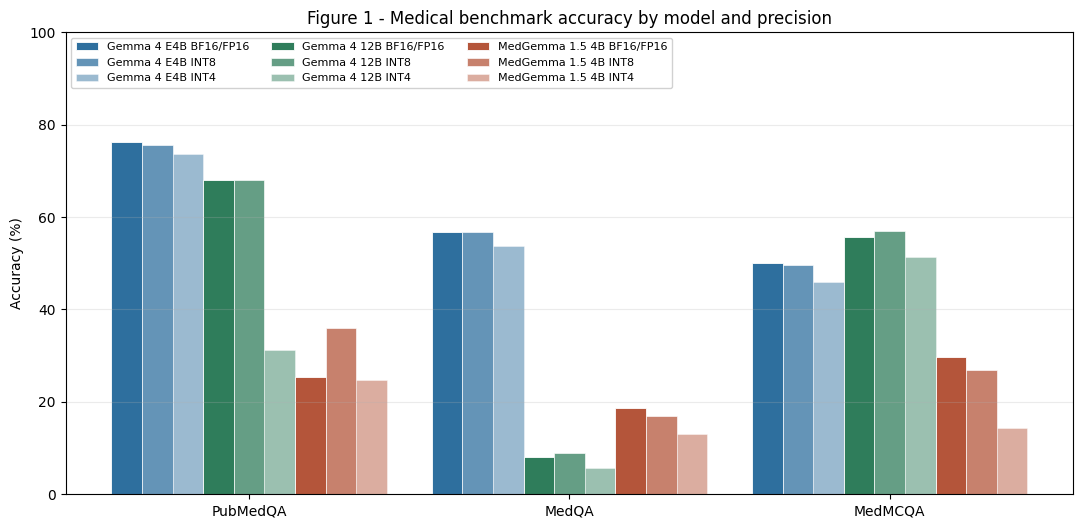

saved 01_medical_accuracy.png


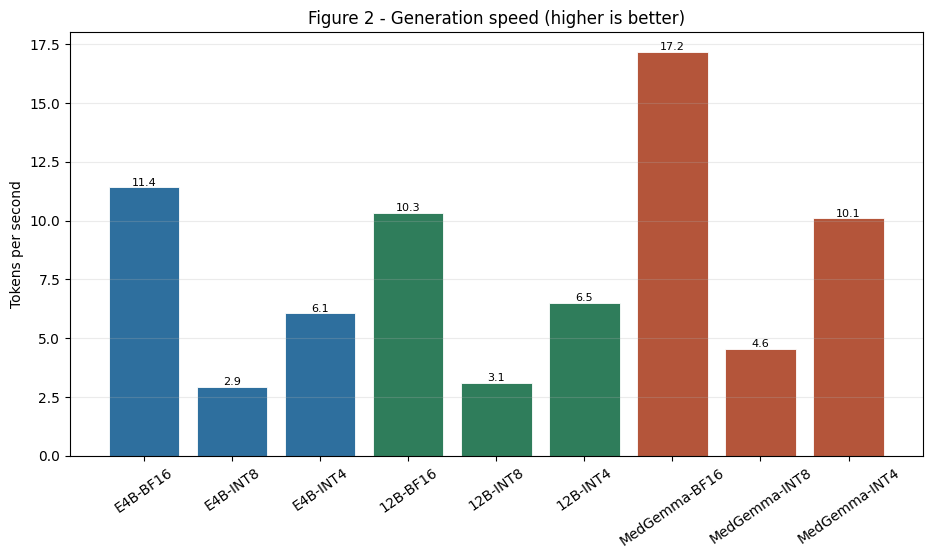

saved 02_tokens_per_second.png


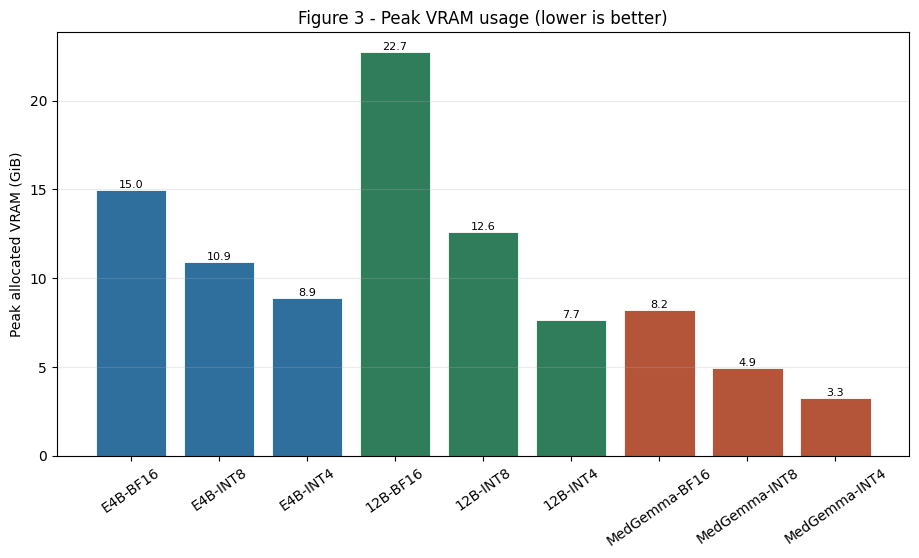

saved 03_peak_vram.png


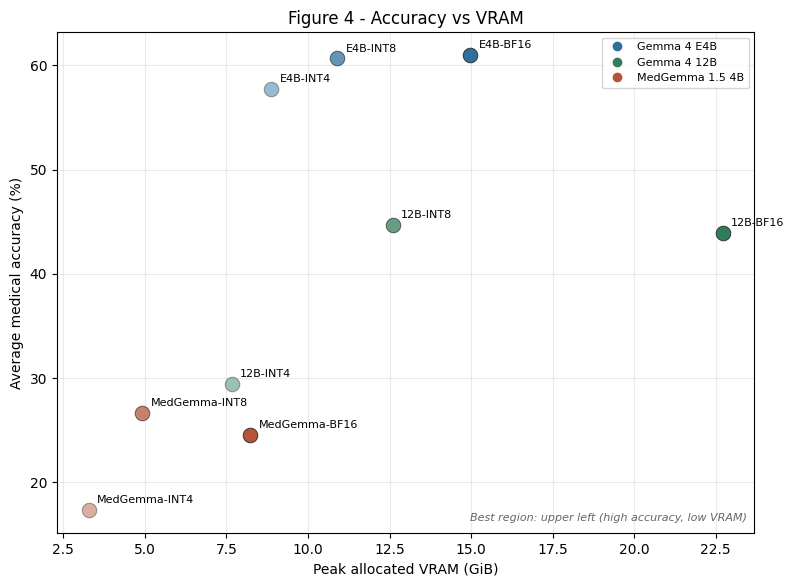

saved 04_accuracy_vs_vram.png


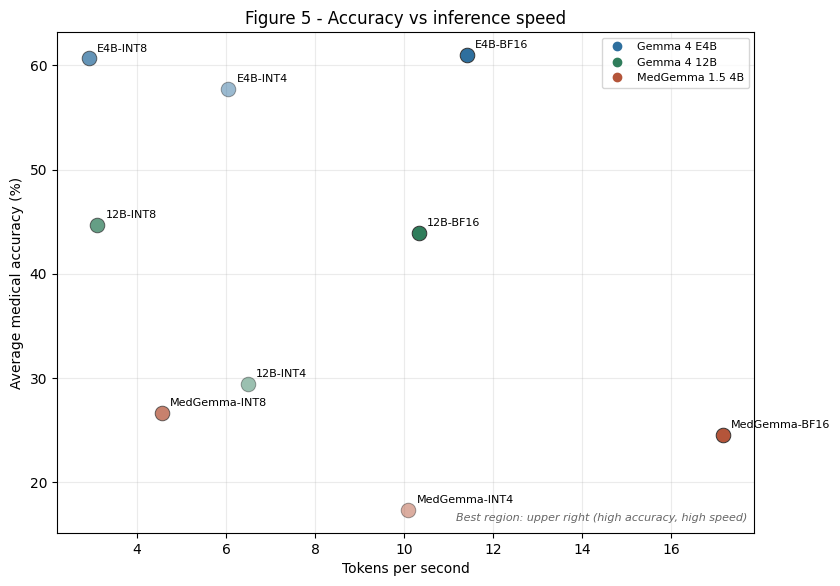

saved 05_accuracy_vs_speed.png


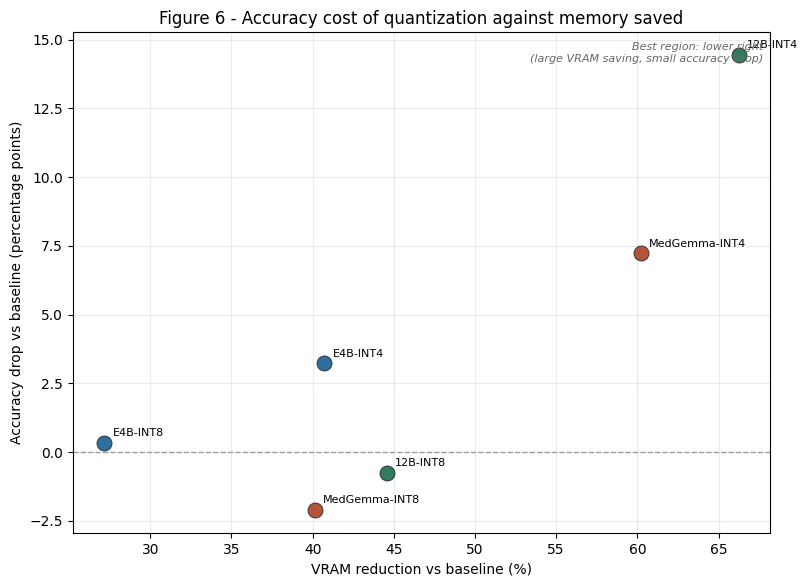

saved 06_accuracy_drop_vs_vram_reduction.png

6 figures written to /content/gemma4_medgemma_clean_results/figures


In [ ]:
FAMILY_COLORS = {"Gemma4-E4B": "#2E6F9E", "Gemma4-12B": "#2F7D5B", "MedGemma": "#B4553A"}
PRECISION_ALPHA = {"Baseline": 1.0, "INT8": 0.74, "INT4-NF4": 0.48}
FALLBACK_COLORS = ["#6C5B8B", "#8A7A2E", "#3F6F72", "#94456B"]

def family_color(family):
    if family in FAMILY_COLORS:
        return FAMILY_COLORS[family]
    return FALLBACK_COLORS[REPORT_FAMILIES.index(family) % len(FALLBACK_COLORS)]

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("saved", path.name)
    return path

def annotate_points(ax, points):
    for x, y, label in points:
        ax.annotate(label, (x, y), xytext=(6, 5), textcoords="offset points", fontsize=8)

def note_missing(ax, count):
    if count:
        ax.text(0.99, 0.02, f"{count} configuration(s) unavailable (N/A)", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=8, style="italic", color="#666666")

saved_figures = []

# --- Figure 1: grouped accuracy by benchmark -------------------------------
plotted = [(f, p) for f, p in REPORT_CONFIGS if pd.notna(average_accuracy(f, p))]
if plotted:
    fig, ax = plt.subplots(figsize=(13, 6))
    positions = np.arange(len(REPORT_BENCHMARKS))
    width = 0.86 / len(plotted)
    for i, (family, precision) in enumerate(plotted):
        scores = ACCURACY_BY_CONFIG.get((family, precision), {})
        values = [scores.get(b, np.nan) * 100 if pd.notna(scores.get(b, np.nan)) else np.nan
                  for b in REPORT_BENCHMARKS]
        ax.bar(positions + i * width - 0.43 + width / 2, values, width,
               label=f"{family_label(family)} {precision_label(precision)}",
               color=family_color(family), alpha=PRECISION_ALPHA.get(precision, 1.0),
               edgecolor="white", linewidth=0.6)
    ax.set_xticks(positions)
    ax.set_xticklabels([BENCHMARK_LABELS.get(b, b) for b in REPORT_BENCHMARKS])
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Figure 1 - Medical benchmark accuracy by model and precision")
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(ncol=3, fontsize=8, loc="upper left", framealpha=0.9)
    note_missing(ax, len(REPORT_CONFIGS) - len(plotted))
    saved_figures.append(save_figure(fig, "01_medical_accuracy.png"))

# --- Figure 2: tokens per second -------------------------------------------
speed_points = [(f, p, metric(PERFORMANCE_INDEX, "tokens_per_second", f, p)) for f, p in REPORT_CONFIGS]
speed_points = [(f, p, v) for f, p, v in speed_points if pd.notna(v)]
if speed_points:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    labels = [short_config_label(f, p) for f, p, _ in speed_points]
    ax.bar(labels, [v for _, _, v in speed_points],
           color=[family_color(f) for f, _, _ in speed_points],
           alpha=1.0, edgecolor="white", linewidth=0.6)
    for i, (_, _, value) in enumerate(speed_points):
        ax.text(i, value, f"{value:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Tokens per second")
    ax.set_title("Figure 2 - Generation speed (higher is better)")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=35)
    note_missing(ax, len(REPORT_CONFIGS) - len(speed_points))
    saved_figures.append(save_figure(fig, "02_tokens_per_second.png"))

# --- Figure 3: peak VRAM ----------------------------------------------------
vram_points = [(f, p, metric(MEMORY_INDEX, "peak_allocated_vram_gib", f, p)) for f, p in REPORT_CONFIGS]
vram_points = [(f, p, v) for f, p, v in vram_points if pd.notna(v)]
if vram_points:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    labels = [short_config_label(f, p) for f, p, _ in vram_points]
    ax.bar(labels, [v for _, _, v in vram_points],
           color=[family_color(f) for f, _, _ in vram_points],
           alpha=1.0, edgecolor="white", linewidth=0.6)
    for i, (_, _, value) in enumerate(vram_points):
        ax.text(i, value, f"{value:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylabel("Peak allocated VRAM (GiB)")
    ax.set_title("Figure 3 - Peak VRAM usage (lower is better)")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=35)
    note_missing(ax, len(REPORT_CONFIGS) - len(vram_points))
    saved_figures.append(save_figure(fig, "03_peak_vram.png"))

# --- Figures 4 and 5: accuracy against cost --------------------------------
def scatter_against_accuracy(x_column, index_frame, xlabel, title, filename, invert_hint):
    points = []
    for family, precision in REPORT_CONFIGS:
        x = metric(index_frame, x_column, family, precision)
        y = average_accuracy(family, precision)
        if pd.notna(x) and pd.notna(y):
            points.append((family, precision, x, y * 100))
    if not points:
        return None
    fig, ax = plt.subplots(figsize=(9, 6.5))
    for family, precision, x, y in points:
        ax.scatter(x, y, s=110, color=family_color(family),
                   alpha=PRECISION_ALPHA.get(precision, 1.0),
                   edgecolor="#333333", linewidth=0.7, zorder=3)
    annotate_points(ax, [(x, y, short_config_label(f, p)) for f, p, x, y in points])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Average medical accuracy (%)")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.text(0.99, 0.02, invert_hint, transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8, style="italic", color="#666666")
    handles = [plt.Line2D([], [], marker="o", linestyle="", color=family_color(f),
                          label=family_label(f)) for f in REPORT_FAMILIES]
    ax.legend(handles=handles, fontsize=8, loc="best")
    return save_figure(fig, filename)

figure4 = scatter_against_accuracy(
    "peak_allocated_vram_gib", MEMORY_INDEX, "Peak allocated VRAM (GiB)",
    "Figure 4 - Accuracy vs VRAM", "04_accuracy_vs_vram.png",
    "Best region: upper left (high accuracy, low VRAM)")
figure5 = scatter_against_accuracy(
    "tokens_per_second", PERFORMANCE_INDEX, "Tokens per second",
    "Figure 5 - Accuracy vs inference speed", "05_accuracy_vs_speed.png",
    "Best region: upper right (high accuracy, high speed)")
saved_figures += [f for f in (figure4, figure5) if f]

# --- Figure 6: accuracy drop against VRAM reduction ------------------------
tradeoff_points = []
for _, row in table4_tradeoff.iterrows():
    if pd.notna(row["Accuracy Drop"]) and pd.notna(row["VRAM Reduction %"]):
        tradeoff_points.append((row["Model"], row["Quantization"],
                                float(row["VRAM Reduction %"]), float(row["Accuracy Drop"]) * 100))
if tradeoff_points:
    inverse_labels = {family_label(f): f for f in REPORT_FAMILIES}
    fig, ax = plt.subplots(figsize=(9, 6.5))
    for model, quant, x, y in tradeoff_points:
        ax.scatter(x, y, s=115, color=family_color(inverse_labels.get(model, model)),
                   edgecolor="#333333", linewidth=0.7, zorder=3)
    annotate_points(ax, [
        (x, y, f"{family_label(inverse_labels.get(m, m), True)}-{q}")
        for m, q, x, y in tradeoff_points])
    ax.axhline(0, color="#999999", linewidth=1, linestyle="--", zorder=1)
    ax.set_xlabel("VRAM reduction vs baseline (%)")
    ax.set_ylabel("Accuracy drop vs baseline (percentage points)")
    ax.set_title("Figure 6 - Accuracy cost of quantization against memory saved")
    ax.grid(alpha=0.25)
    ax.text(0.99, 0.98, "Best region: lower right\n(large VRAM saving, small accuracy drop)",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            style="italic", color="#666666")
    saved_figures.append(save_figure(fig, "06_accuracy_drop_vs_vram_reduction.png"))

print(f"\n{len(saved_figures)} figures written to {FIGURE_DIR}")

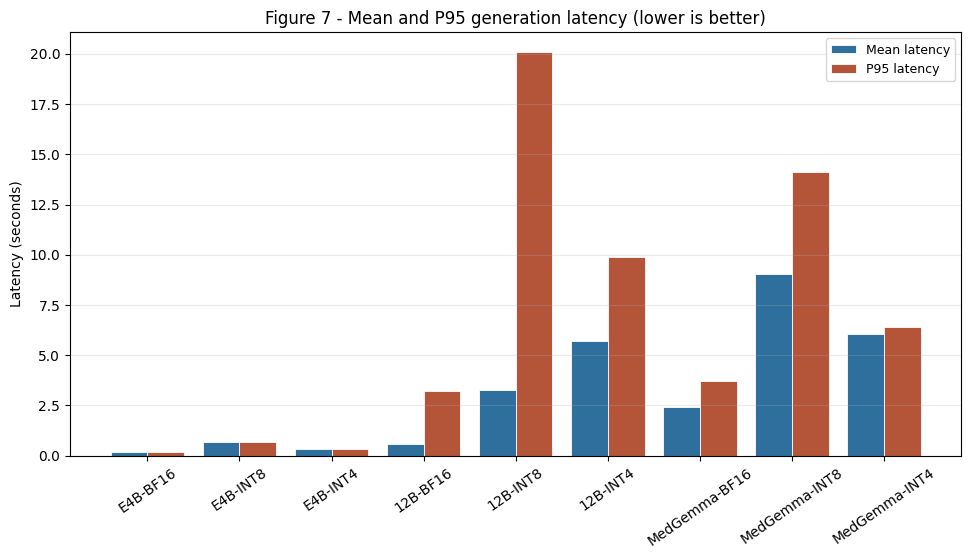

saved 07_latency_comparison.png


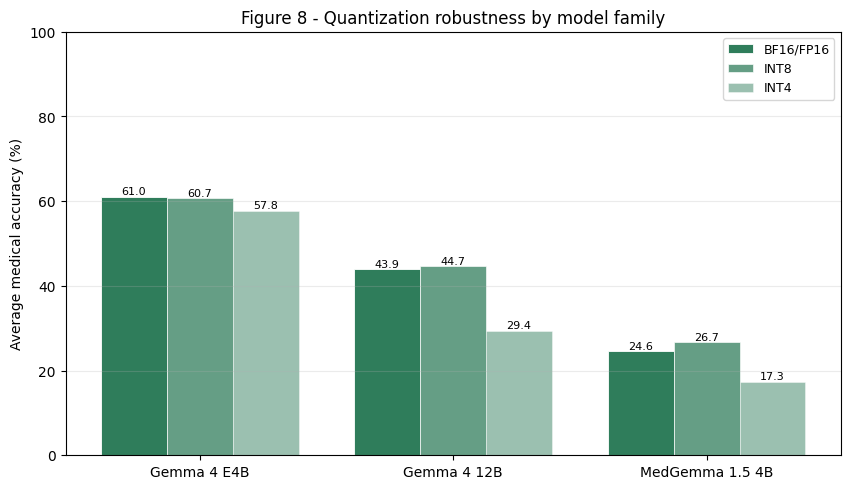

saved 08_quantization_robustness.png

Total figures in /content/gemma4_medgemma_clean_results/figures: 8


In [ ]:
# --- Figure 7: latency comparison ------------------------------------------
latency_points = []
for family, precision in REPORT_CONFIGS:
    mean_latency = metric(PERFORMANCE_INDEX, "mean_latency_seconds", family, precision)
    p95_latency = metric(PERFORMANCE_INDEX, "p95_latency_seconds", family, precision)
    if pd.notna(mean_latency) or pd.notna(p95_latency):
        latency_points.append((family, precision, mean_latency, p95_latency))

if latency_points:
    fig, ax = plt.subplots(figsize=(11.5, 5.5))
    positions = np.arange(len(latency_points))
    ax.bar(positions - 0.2, [m for _, _, m, _ in latency_points], 0.4,
           label="Mean latency", color="#2E6F9E", edgecolor="white", linewidth=0.6)
    ax.bar(positions + 0.2, [p for _, _, _, p in latency_points], 0.4,
           label="P95 latency", color="#B4553A", edgecolor="white", linewidth=0.6)
    ax.set_xticks(positions)
    ax.set_xticklabels([short_config_label(f, p) for f, p, _, _ in latency_points], rotation=35)
    ax.set_ylabel("Latency (seconds)")
    ax.set_title("Figure 7 - Mean and P95 generation latency (lower is better)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=9)
    note_missing(ax, len(REPORT_CONFIGS) - len(latency_points))
    saved_figures.append(save_figure(fig, "07_latency_comparison.png"))
else:
    print("Figure 7 skipped: no latency measurements available.")

# --- Figure 8: quantization robustness by family ---------------------------
robust_families = [f for f in REPORT_FAMILIES
                   if any(pd.notna(average_accuracy(f, p)) for p in PRECISION_ORDER)]
if robust_families:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    positions = np.arange(len(robust_families))
    width = 0.26
    for i, precision in enumerate(PRECISION_ORDER):
        values = [average_accuracy(f, precision) * 100
                  if pd.notna(average_accuracy(f, precision)) else np.nan
                  for f in robust_families]
        ax.bar(positions + (i - 1) * width, values, width,
               label=precision_label(precision), color="#2F7D5B",
               alpha=PRECISION_ALPHA.get(precision, 1.0), edgecolor="white", linewidth=0.6)
        for x, value in zip(positions + (i - 1) * width, values):
            if pd.notna(value):
                ax.text(x, value, f"{value:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(positions)
    ax.set_xticklabels([family_label(f) for f in robust_families])
    ax.set_ylabel("Average medical accuracy (%)")
    ax.set_title("Figure 8 - Quantization robustness by model family")
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=9)
    saved_figures.append(save_figure(fig, "08_quantization_robustness.png"))
else:
    print("Figure 8 skipped: no accuracy results available.")

print(f"\nTotal figures in {FIGURE_DIR}: {len(sorted(FIGURE_DIR.glob('*.png')))}")

## 18. Final Evidence-Only Analysis


In [ ]:
def best_by(values, largest=True):
    '''Return (label, value) of the best available measurement, or None when none exist.'''
    usable = [(label, value) for label, value in values if pd.notna(value)]
    if not usable:
        return None
    return max(usable, key=lambda kv: kv[1]) if largest else min(usable, key=lambda kv: kv[1])

analysis = ["## Final analysis", "",
            "Every statement below is derived from completed measurements only. "
            "Questions without sufficient data are reported as unanswerable rather than estimated.", ""]

accuracy_values = [(short_config_label(f, p), average_accuracy(f, p)) for f, p in REPORT_CONFIGS]
speed_values = [(short_config_label(f, p), metric(PERFORMANCE_INDEX, "tokens_per_second", f, p))
                for f, p in REPORT_CONFIGS]
vram_values = [(short_config_label(f, p), metric(MEMORY_INDEX, "peak_allocated_vram_gib", f, p))
               for f, p in REPORT_CONFIGS]

# 1-3 -----------------------------------------------------------------------
top_accuracy = best_by(accuracy_values, largest=True)
analysis.append("**1. Highest average medical accuracy**")
analysis.append(f"{top_accuracy[0]} at {top_accuracy[1] * 100:.2f}%." if top_accuracy
                else "No configuration produced accuracy results.")

top_speed = best_by(speed_values, largest=True)
analysis += ["", "**2. Fastest configuration**"]
analysis.append(f"{top_speed[0]} at {top_speed[1]:.2f} tokens/s." if top_speed
                else "No configuration produced speed measurements.")

low_vram = best_by(vram_values, largest=False)
analysis += ["", "**3. Lowest VRAM**"]
analysis.append(f"{low_vram[0]} at {low_vram[1]:.2f} GiB peak allocated." if low_vram
                else "No configuration produced memory measurements.")

# 4-5 -----------------------------------------------------------------------
def best_preserving(precision):
    rows = table4_tradeoff[table4_tradeoff["Quantization"] == precision_label(precision)]
    rows = rows.dropna(subset=["Accuracy Drop"])
    if rows.empty:
        return None
    best = rows.loc[rows["Accuracy Drop"].idxmin()]
    return best["Model"], float(best["Accuracy Drop"])

for number, precision in ((4, "INT8"), (5, "INT4-NF4")):
    result = best_preserving(precision)
    analysis += ["", f"**{number}. {precision_label(precision)} configuration that preserved accuracy best**"]
    if result:
        name, drop = result
        direction = "lost" if drop >= 0 else "gained"
        analysis.append(f"{name}: {direction} {abs(drop) * 100:.2f} percentage points versus its own baseline.")
    else:
        analysis.append(f"No family completed both a baseline and an {precision_label(precision)} run.")

# 6-7 -----------------------------------------------------------------------
def normalize(series):
    '''Min-max scale to [0, 1]; a flat series scores 1 everywhere.'''
    spread = series.max() - series.min()
    return (series - series.min()) / spread if spread else pd.Series(1.0, index=series.index)

def best_balanced(cost_values, lower_cost_is_better):
    '''Rank equally on normalized accuracy and normalized cost, as Section 19 does.'''
    rows = [{"name": name, "accuracy": accuracy, "cost": cost}
            for (name, accuracy), (_, cost) in zip(accuracy_values, cost_values)
            if pd.notna(accuracy) and pd.notna(cost)]
    if not rows:
        return None
    frame = pd.DataFrame(rows)
    cost_score = 1 - normalize(frame["cost"]) if lower_cost_is_better else normalize(frame["cost"])
    frame["score"] = (normalize(frame["accuracy"]) + cost_score) / 2
    best = frame.loc[frame["score"].idxmax()]
    return best["name"], float(best["accuracy"]), float(best["cost"])

vram_balance = best_balanced(vram_values, lower_cost_is_better=True)
analysis += ["", "**6. Best accuracy-to-VRAM trade-off**"]
analysis.append(
    f"{vram_balance[0]}: {vram_balance[1] * 100:.2f}% accuracy at {vram_balance[2]:.2f} GiB peak VRAM. "
    "Ranked with equal weight on normalized accuracy and normalized memory saving."
    if vram_balance else "Needs both accuracy and VRAM measurements; not available.")

speed_balance = best_balanced(speed_values, lower_cost_is_better=False)
analysis += ["", "**7. Best accuracy-to-speed trade-off**"]
analysis.append(
    f"{speed_balance[0]}: {speed_balance[1] * 100:.2f}% accuracy at {speed_balance[2]:.2f} tokens/s. "
    "Ranked with equal weight on normalized accuracy and normalized speed."
    if speed_balance else "Needs both accuracy and speed measurements; not available.")

# 8-9 -----------------------------------------------------------------------
MEDICAL_FAMILY = "MedGemma"
general_families = [f for f in REPORT_FAMILIES if f != MEDICAL_FAMILY]

analysis += ["", "**8. Does MedGemma outperform general-purpose Gemma 4 on medical benchmarks?**"]
medical_best = best_by([(short_config_label(MEDICAL_FAMILY, p), average_accuracy(MEDICAL_FAMILY, p))
                        for p in PRECISION_ORDER], largest=True) if MEDICAL_FAMILY in REPORT_FAMILIES else None
general_best = best_by([(short_config_label(f, p), average_accuracy(f, p))
                        for f in general_families for p in PRECISION_ORDER], largest=True)
if medical_best and general_best:
    gap = (medical_best[1] - general_best[1]) * 100
    verdict = ("Yes" if gap > 0 else "No" if gap < 0 else "Tie")
    analysis.append(
        f"{verdict}. Best MedGemma configuration {medical_best[0]} reached {medical_best[1] * 100:.2f}%, "
        f"against {general_best[0]} at {general_best[1] * 100:.2f}% "
        f"(difference {gap:+.2f} percentage points). Note this compares best-of-family, not matched precision.")
else:
    analysis.append("Unanswerable: results are missing for MedGemma or for every general-purpose family.")

LARGE_FAMILY = "Gemma4-12B"
analysis += ["", "**9. Does Gemma 4 12B compensate for the lack of medical specialisation through scale?**"]
large_baseline = average_accuracy(LARGE_FAMILY, "Baseline") if LARGE_FAMILY in REPORT_FAMILIES else math.nan
medical_baseline = average_accuracy(MEDICAL_FAMILY, "Baseline") if MEDICAL_FAMILY in REPORT_FAMILIES else math.nan
if pd.notna(large_baseline) and pd.notna(medical_baseline):
    gap = (large_baseline - medical_baseline) * 100
    verdict = "Yes" if gap > 0 else "No" if gap < 0 else "Tie"
    analysis.append(
        f"{verdict}, at matched BF16/FP16 precision. {family_label(LARGE_FAMILY)} scored "
        f"{large_baseline * 100:.2f}% against {family_label(MEDICAL_FAMILY)} at {medical_baseline * 100:.2f}% "
        f"({gap:+.2f} percentage points).")
else:
    analysis.append("Unanswerable: the baseline run is missing for at least one of the two families.")

# 10 ------------------------------------------------------------------------
analysis += ["", "**10. Recommendation under limited GPU memory**"]
candidates = []
for (name, accuracy), (_, vram) in zip(accuracy_values, vram_values):
    if pd.notna(accuracy) and pd.notna(vram):
        candidates.append((name, accuracy, vram))
if candidates:
    fits_16gb = [c for c in candidates if c[2] <= 15.0]
    pool = fits_16gb or candidates
    recommended = max(pool, key=lambda item: item[1])
    scope = "fitting within a 16 GB GPU" if fits_16gb else "measured (none fit within 16 GB)"
    analysis.append(
        f"Among configurations {scope}, **{recommended[0]}** gives the highest accuracy "
        f"({recommended[1] * 100:.2f}%) at {recommended[2]:.2f} GiB peak VRAM.")
    analysis.append("This ranks measured accuracy against measured memory only. It is not a clinical "
                    "deployment recommendation and does not account for safety, calibration, or licensing.")
else:
    analysis.append("Unanswerable: no configuration has both accuracy and memory measurements.")

missing = [short_config_label(f, p) for f, p in REPORT_CONFIGS if pd.isna(average_accuracy(f, p))]
if missing:
    analysis += ["", "**Configurations without results (reported as N/A above)**", ", ".join(missing) + "."]

final_analysis_text = "\n".join(analysis)
display(Markdown(final_analysis_text))
(Path(OUTPUT_DIR) / "final_analysis.md").write_text(final_analysis_text, encoding="utf-8")

archive_path = shutil.make_archive(OUTPUT_DIR, "zip", root_dir=OUTPUT_DIR)
print(f"\nAnalysis written to final_analysis.md")
print(f"Archive rebuilt: {archive_path}")

## Final analysis

Every statement below is derived from completed measurements only. Questions without sufficient data are reported as unanswerable rather than estimated.

**1. Highest average medical accuracy**
E4B-BF16 at 61.00%.

**2. Fastest configuration**
MedGemma-BF16 at 17.15 tokens/s.

**3. Lowest VRAM**
MedGemma-INT4 at 3.27 GiB peak allocated.

**4. INT8 configuration that preserved accuracy best**
MedGemma 1.5 4B: gained 2.11 percentage points versus its own baseline.

**5. INT4 configuration that preserved accuracy best**
Gemma 4 E4B: lost 3.22 percentage points versus its own baseline.

**6. Best accuracy-to-VRAM trade-off**
E4B-INT4: 57.78% accuracy at 8.88 GiB peak VRAM. Ranked with equal weight on normalized accuracy and normalized memory saving.

**7. Best accuracy-to-speed trade-off**
E4B-BF16: 61.00% accuracy at 11.41 tokens/s. Ranked with equal weight on normalized accuracy and normalized speed.

**8. Does MedGemma outperform general-purpose Gemma 4 on medical benchmarks?**
No. Best MedGemma configuration MedGemma-INT8 reached 26.67%, against E4B-BF16 at 61.00% (difference -34.33 percentage points). Note this compares best-of-family, not matched precision.

**9. Does Gemma 4 12B compensate for the lack of medical specialisation through scale?**
Yes, at matched BF16/FP16 precision. Gemma 4 12B scored 43.89% against MedGemma 1.5 4B at 24.56% (+19.33 percentage points).

**10. Recommendation under limited GPU memory**
Among configurations fitting within a 16 GB GPU, **E4B-BF16** gives the highest accuracy (61.00%) at 14.97 GiB peak VRAM.
This ranks measured accuracy against measured memory only. It is not a clinical deployment recommendation and does not account for safety, calibration, or licensing.


Analysis written to final_analysis.md
Archive rebuilt: /content/gemma4_medgemma_clean_results.zip


In [ ]:
from google.colab import drive
from pathlib import Path
import shutil
from datetime import datetime

drive.mount("/content/drive")

RUN_NAME = datetime.now().strftime("gemma4_medgemma_results_%Y%m%d_%H%M%S")

DRIVE_RESULTS_DIR = Path("/content/drive/MyDrive/gemma4_medgemma_benchmark_results") / RUN_NAME
DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

source_dir = Path(OUTPUT_DIR)

if not source_dir.exists():
    raise FileNotFoundError(f"OUTPUT_DIR does not exist: {source_dir}")

shutil.copytree(source_dir, DRIVE_RESULTS_DIR, dirs_exist_ok=True)

zip_base = Path("/content/drive/MyDrive/gemma4_medgemma_benchmark_results") / RUN_NAME
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=source_dir)

print("Saved results folder to Google Drive:")
print(DRIVE_RESULTS_DIR)

print("Saved ZIP archive to Google Drive:")
print(zip_path)

Mounted at /content/drive
Saved results folder to Google Drive:
/content/drive/MyDrive/gemma4_medgemma_benchmark_results/gemma4_medgemma_results_20260811_031656
Saved ZIP archive to Google Drive:
/content/drive/MyDrive/gemma4_medgemma_benchmark_results/gemma4_medgemma_results_20260811_031656.zip


In [ ]:
from huggingface_hub import HfApi, notebook_login
from pathlib import Path
from datetime import datetime

notebook_login()

api = HfApi()

HF_NAMESPACE = None  # ใส่ username/org เองได้ เช่น "your-username"; ถ้า None จะใช้ account ที่ login
HF_REPO_NAME = "gemma4-medgemma-benchmark-results"
HF_PRIVATE = True

whoami = api.whoami()
namespace = HF_NAMESPACE or whoami["name"]
repo_id = f"{namespace}/{HF_REPO_NAME}"

api.create_repo(
    repo_id=repo_id,
    repo_type="dataset",
    private=HF_PRIVATE,
    exist_ok=True,
)

run_name = datetime.now().strftime("run_%Y%m%d_%H%M%S")

api.upload_folder(
    repo_id=repo_id,
    repo_type="dataset",
    folder_path=str(Path(OUTPUT_DIR)),
    path_in_repo=run_name,
    commit_message=f"Upload Gemma 4 + MedGemma benchmark results: {run_name}",
)

print("Uploaded benchmark results to Hugging Face:")
print(f"https://huggingface.co/datasets/{repo_id}")
print("Path in repo:", run_name)

Uploaded benchmark results to Hugging Face:
https://huggingface.co/datasets/pupupapapa/gemma4-medgemma-benchmark-results
Path in repo: run_20260811_031707


In [ ]:
from huggingface_hub import HfApi, notebook_login
from pathlib import Path
import gc
import torch
import traceback

notebook_login()

api = HfApi()

HF_NAMESPACE = None  # เช่น "your-username"; ถ้า None จะใช้ account ที่ login
HF_PRIVATE = True

whoami = api.whoami()
namespace = HF_NAMESPACE or whoami["name"]

QUANTIZED_UPLOAD_TARGETS = []
for family in ACTIVE_FAMILIES:
    model_id = MODEL_FAMILIES[family]["model_id"]
    revision = MODEL_FAMILIES[family].get("revision")

    for precision in ["INT8", "INT4-NF4"]:
        if precision not in ACTIVE_PRECISIONS:
            continue

        source_name = model_id.split("/")[-1].lower()
        precision_name = precision.lower().replace("-nf4", "").replace("-", "-")
        repo_name = f"{source_name}-{precision_name}-bnb"

        QUANTIZED_UPLOAD_TARGETS.append({
            "family": family,
            "model_id": model_id,
            "revision": revision,
            "precision": precision,
            "repo_id": f"{namespace}/{repo_name}",
        })

print("Upload plan:")
for target in QUANTIZED_UPLOAD_TARGETS:
    print(f"- {target['family']} {target['precision']} -> {target['repo_id']}")

UPLOAD_QUANTIZED_MODELS = True

if not UPLOAD_QUANTIZED_MODELS:
    print("UPLOAD_QUANTIZED_MODELS is False; nothing uploaded.")
else:
    upload_records = []

    for target in QUANTIZED_UPLOAD_TARGETS:
        family = target["family"]
        model_id = target["model_id"]
        revision = target["revision"]
        precision = target["precision"]
        repo_id = target["repo_id"]

        model = None
        processor = None

        try:
            print(f"\n=== Uploading {family} {precision} ===")
            print("Source:", model_id)
            print("Target:", repo_id)

            unload_model()
            if torch.cuda.is_available():
                torch.cuda.reset_peak_memory_stats()

            api.create_repo(
                repo_id=repo_id,
                repo_type="model",
                private=HF_PRIVATE,
                exist_ok=True,
            )

            processor = load_family_processor(model_id, revision)
            model, actual_dtype, quant_method = load_family_model(model_id, revision, precision)

            model.push_to_hub(
                repo_id,
                private=HF_PRIVATE,
                safe_serialization=True,
                commit_message=f"Upload {family} {precision} BitsAndBytes quantized checkpoint",
            )

            companion = processor.processor if hasattr(processor, "processor") else processor
            companion.push_to_hub(
                repo_id,
                private=HF_PRIVATE,
                commit_message=f"Upload processor for {family} {precision}",
            )

            model_card = f"""---
license: gemma
base_model: {model_id}
library_name: transformers
tags:
- gemma
- medgemma
- quantized
- bitsandbytes
- int8
- int4
- medical-benchmark
---

# {family} {precision} BitsAndBytes Quantized Checkpoint

Source model: `{model_id}`  
Precision: `{precision}`  
Quantization method: `{quant_method}`  
Actual dtype: `{actual_dtype}`  

This repository was created from the benchmark notebook and stores a BitsAndBytes quantized checkpoint.

## Notes

- Baseline BF16/FP16 is not uploaded because it is the original upstream model.
- INT8 uses `BitsAndBytesConfig(load_in_8bit=True)`.
- INT4 uses NF4 with double quantization.
- Benchmark results are not claimed in this model card unless added separately.
"""

            api.upload_file(
                repo_id=repo_id,
                repo_type="model",
                path_or_fileobj=model_card.encode("utf-8"),
                path_in_repo="README.md",
                commit_message=f"Add model card for {family} {precision}",
            )

            upload_records.append({
                "family": family,
                "precision": precision,
                "source_model": model_id,
                "repo_id": repo_id,
                "actual_dtype": actual_dtype,
                "quantization_method": quant_method,
                "error": None,
            })

            print("Uploaded:", f"https://huggingface.co/{repo_id}")

        except Exception as exc:
            error = f"{type(exc).__name__}: {exc}"
            upload_records.append({
                "family": family,
                "precision": precision,
                "source_model": model_id,
                "repo_id": repo_id,
                "error": error,
                "traceback": traceback.format_exc(),
            })
            print("FAILED:", error)

        finally:
            del model
            del processor
            unload_model()

    upload_records_df = pd.DataFrame(upload_records)
    upload_records_df.to_csv(Path(OUTPUT_DIR) / "quantized_model_upload_records.csv", index=False)

    display(upload_records_df)

Upload plan:
- Gemma4-E4B INT8 -> pupupapapa/gemma-4-e4b-it-int8-bnb
- Gemma4-E4B INT4-NF4 -> pupupapapa/gemma-4-e4b-it-int4-bnb
- Gemma4-12B INT8 -> pupupapapa/gemma-4-12b-it-int8-bnb
- Gemma4-12B INT4-NF4 -> pupupapapa/gemma-4-12b-it-int4-bnb
- MedGemma INT8 -> pupupapapa/medgemma-1.5-4b-it-int8-bnb
- MedGemma INT4-NF4 -> pupupapapa/medgemma-1.5-4b-it-int4-bnb

=== Uploading Gemma4-E4B INT8 ===
Source: google/gemma-4-E4B-it
Target: pupupapapa/gemma-4-e4b-it-int8-bnb


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

FAILED: TypeError: PushToHubMixin.push_to_hub() got an unexpected keyword argument 'safe_serialization'

=== Uploading Gemma4-E4B INT4-NF4 ===
Source: google/gemma-4-E4B-it
Target: pupupapapa/gemma-4-e4b-it-int4-bnb


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


...

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

FAILED: TypeError: PushToHubMixin.push_to_hub() got an unexpected keyword argument 'safe_serialization'

=== Uploading MedGemma INT4-NF4 ===
Source: google/medgemma-1.5-4b-it
Target: pupupapapa/medgemma-1.5-4b-it-int4-bnb


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

FAILED: TypeError: PushToHubMixin.push_to_hub() got an unexpected keyword argument 'safe_serialization'


,family,precision,source_model,repo_id,error,traceback
0,Gemma4-E4B,INT8,google/gemma-4-E4B-it,pupupapapa/gemma-4-e4b-it-int8-bnb,TypeError: PushToHubMixin.push_to_hub() got an...,"Traceback (most recent call last):\n File ""/t..."
1,Gemma4-E4B,INT4-NF4,google/gemma-4-E4B-it,pupupapapa/gemma-4-e4b-it-int4-bnb,TypeError: PushToHubMixin.push_to_hub() got an...,"Traceback (most recent call last):\n File ""/t..."
2,Gemma4-12B,INT8,google/gemma-4-12B-it,pupupapapa/gemma-4-12b-it-int8-bnb,TypeError: PushToHubMixin.push_to_hub() got an...,"Traceback (most recent call last):\n File ""/t..."
3,Gemma4-12B,INT4-NF4,google/gemma-4-12B-it,pupupapapa/gemma-4-12b-it-int4-bnb,TypeError: PushToHubMixin.push_to_hub() got an...,"Traceback (most recent call last):\n File ""/t..."
4,MedGemma,INT8,google/medgemma-1.5-4b-it,pupupapapa/medgemma-1.5-4b-it-int8-bnb,TypeError: PushToHubMixin.push_to_hub() got an...,"Traceback (most recent call last):\n File ""/t..."
5,MedGemma,INT4-NF4,google/medgemma-1.5-4b-it,pupupapapa/medgemma-1.5-4b-it-int4-bnb,TypeError: PushToHubMixin.push_to_hub() got an...,"Traceback (most recent call last):\n File ""/t..."


In [ ]:
from google.colab import drive
from pathlib import Path
import shutil

drive.mount("/content/drive")

DRIVE_DIR = Path("/content/drive/MyDrive/gemma4_medgemma_benchmark_results")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

for filename in ["experiment_config.json", "sample_ids.json"]:
    src = Path(OUTPUT_DIR) / filename
    dst = DRIVE_DIR / filename

    if src.exists():
        shutil.copy2(src, dst)
        print("Copied:", src, "->", dst)
    else:
        print("Missing:", src)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied: /content/gemma4_medgemma_clean_results/experiment_config.json -> /content/drive/MyDrive/gemma4_medgemma_benchmark_results/experiment_config.json
Copied: /content/gemma4_medgemma_clean_results/sample_ids.json -> /content/drive/MyDrive/gemma4_medgemma_benchmark_results/sample_ids.json


## Outputs

Results are saved under `OUTPUT_DIR`:

- raw predictions
- benchmark summary
- performance summary
- memory summary
- failures JSON
- comparison CSV files
- figures PNG files
- final analysis markdown
